# 📊 Comprehensive EDA Lab — Marketing Analytics Dataset
**Course:** Predictive Analytics in Business | **Level:** Intermediate

---
**Learning Objectives**
- Master every major EDA technique from univariate to multivariate
- Detect and fix real data quality issues
- Apply statistical tests to validate observations
- Build interactive visualizations for business storytelling

**Dataset:** `EDA_Marketing.csv` — ~7,500 rows, 38 features, 12 months of campaign data

> 💡 *Run cells in order. Every `💡 Try:` comment is a self-guided experiment.*

---
## 0. Setup — Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import missingno as msno
import warnings
import scipy.stats as stats
from scipy.stats import (shapiro, levene, mannwhitneyu, kruskal,
                          ks_2samp, chi2_contingency, pearsonr, spearmanr)
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', '{:.3f}'.format)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)

print('✓ All libraries loaded')
print(f'pandas {pd.__version__} | numpy {np.__version__}')

✓ All libraries loaded
pandas 2.2.2 | numpy 2.0.2


---
## Section A: Data Loading & Initial Inspection

In [4]:
# ── A1. Load data and print the Shape
df = pd.read_csv('EDA_Marketing.csv', low_memory=False)
print(f'Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Memory usage: {df.memory_usage(deep=True).sum() / 1e6:.2f} MB')

Shape: 7,687 rows × 38 columns
Memory usage: 7.88 MB


In [5]:
# ── A2. First / last look
print('=== FIRST 5 ROWS ===')
display(df.head())
print('=== LAST 5 ROWS ===')
display(df.tail())

=== FIRST 5 ROWS ===


,Date,Month,Quarter,Day_of_Week,Season,Holiday_Flag,Customer_ID,Age,Gender,Income_Level,Location,Region,Customer_Tenure,Customer_Segment,Channel,Campaign_Name,Campaign_Type,Impressions,Clicks,CTR,Cost_per_Click,Total_Spend,Website_Visits,Pages_Per_Visit,Time_on_Site,Bounce_Rate,Social_Media_Interactions,Conversions,Product_Category,Purchase_Frequency,Average_Order_Value,Conversion_Value,Conversion_Rate,Customer_Satisfaction_Score,NPS_Score,Churn_Risk,LTV,Competitor_Activity_Index
0,2023-05-03,5,2,Wednesday,Spring,No,CUST-102423,30.000,Male,Low,Suburban,East,83,Basic,Email,Loyalty_Boost,Retention,39469.000,3624.000,0.092,0.920,3334.080,475.000,5.490,8.360,26.510,137.000,0,Health & Beauty,9.000,68.430,0.000,0.000,7.000,0.000,Low,864.180,7.110
1,2023-08-10,8,3,Thursday,Summer,No,CUST-104454,44.000,M,Low,Suburban,East,73,Standard,Social Media,Holiday_Rush,Retention,19591.000,2635.000,0.135,1.350,3557.250,438.000,10.540,14.950,59.210,804.000,0,Apparel,18.000,64.510,0.000,0.000,2.000,0.000,Medium,1493.250,68.790
2,2023-06-07,6,2,Wednesday,Summer,No,CUST-103136,19.000,Male,Mid,Suburban,West,87,Premium,Display Ads,Back_to_School,Acquisition,48255.000,4861.000,0.101,2.470,12006.670,84.000,5.600,8.390,20.360,477.000,0,Sports,2.000,53.090,0.000,0.000,NaN,2.000,High,140.770,33.910
3,2023-08-10,8,3,Thursday,Summer,No,CUST-104456,59.000,F,High,Suburban,West,14,Basic,Display Ads,Spring_Sale,Acquisition,4633.000,569.000,0.123,4.920,2799.480,478.000,4.880,6.280,87.970,684.000,0,Home & Garden,10.000,69.720,0.000,0.000,3.000,10.000,Low,649.260,64.460
4,2023-08-28,8,3,Monday,Summer,No,CUST-104831,33.000,Female,Mid,Rural,West,9,Basic,Paid Search,Spring_Sale,Acquisition,34059.000,1562.000,0.046,2.690,4201.780,437.000,1.520,7.880,78.740,922.000,0,Health & Beauty,3.000,37.120,0.000,0.000,6.000,4.000,Low,107.470,62.500


=== LAST 5 ROWS ===


,Date,Month,Quarter,Day_of_Week,Season,Holiday_Flag,Customer_ID,Age,Gender,Income_Level,Location,Region,Customer_Tenure,Customer_Segment,Channel,Campaign_Name,Campaign_Type,Impressions,Clicks,CTR,Cost_per_Click,Total_Spend,Website_Visits,Pages_Per_Visit,Time_on_Site,Bounce_Rate,Social_Media_Interactions,Conversions,Product_Category,Purchase_Frequency,Average_Order_Value,Conversion_Value,Conversion_Rate,Customer_Satisfaction_Score,NPS_Score,Churn_Risk,LTV,Competitor_Activity_Index
7682,2023-03-28,3,1,Tuesday,Spring,No,CUST-101737,47.000,Female,Low,Suburban,East,90,Standard,Social Media,Back_to_School,Acquisition,17231.000,206.000,0.012,2.990,615.940,405.000,9.280,5.630,32.290,378.000,0,Home & Garden,12.000,46.010,0.000,0.000,7.000,5.000,High,465.760,9.210
7683,2023-06-11,6,2,Sunday,Summer,No,CUST-103240,33.000,M,Low,Urban,South,84,Premium,Social Media,Summer_Blast,Branding,22602.000,2431.000,0.108,0.400,972.400,325.000,5.480,3.850,25.570,434.000,0,Home & Garden,11.000,41.010,0.000,0.000,1.000,1.000,Medium,436.220,60.710
7684,2023-09-21,9,3,Thursday,Fall,No,CUST-105305,39.000,Non-binary,Low,Suburban,West,48,Basic,Paid Search,Loyalty_Boost,Retention,3756.000,104.000,0.028,1.610,167.440,470.000,7.330,9.250,45.520,531.000,0,Apparel,10.000,41.480,0.000,0.000,2.000,6.000,Medium,530.980,7.810
7685,2023-12-18,12,4,Monday,Winter,No,CUST-107203,41.000,Female,High,Rural,South,8,Premium,Direct,Holiday_Rush,Retention,10828.000,1059.000,0.098,4.470,4733.730,445.000,7.260,10.010,59.660,269.000,0,Home & Garden,1.000,299.200,0.000,0.000,3.000,7.000,Low,434.470,47.170
7686,2023-08-23,8,3,Wednesday,Summer,No,CUST-104737,36.000,Female,High,Urban,East,27,Standard,Email,Holiday_Rush,Retention,13436.000,411.000,0.031,0.990,NaN,464.000,8.140,9.190,26.780,319.000,0,Home & Garden,17.000,163.030,0.000,0.000,8.000,8.000,High,2803.120,42.120


In [8]:
# ── A3. Data types & info
df.info(verbose=True, show_counts=True)

# verbose=True means "give me all the details." When a function runs with verbose=True,
# It prints out a complete, extensive report of what it is doing or finding, rather than a short or summarized version.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7687 entries, 0 to 7686
Data columns (total 38 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Date                         7687 non-null   object 
 1   Month                        7687 non-null   int64  
 2   Quarter                      7687 non-null   int64  
 3   Day_of_Week                  7687 non-null   object 
 4   Season                       7687 non-null   object 
 5   Holiday_Flag                 7687 non-null   object 
 6   Customer_ID                  7687 non-null   object 
 7   Age                          7342 non-null   float64
 8   Gender                       7687 non-null   object 
 9   Income_Level                 7435 non-null   object 
 10  Location                     7687 non-null   object 
 11  Region                       7687 non-null   object 
 12  Customer_Tenure              7687 non-null   int64  
 13  Customer_Segment  

In [9]:
# ── A4. Column overview table
overview = pd.DataFrame({
    'dtype':   df.dtypes,
    'nunique': df.nunique(),
    'nulls':   df.isnull().sum(),
    'null_%':  (df.isnull().mean()*100).round(2),
    'sample':  [df[c].dropna().iloc[0] if df[c].notna().any() else 'ALL NULL' for c in df.columns]
})
display(overview)

,dtype,nunique,nulls,null_%,sample
Date,object,414,0,0.000,2023-05-03
Month,int64,12,0,0.000,5
Quarter,int64,4,0,0.000,2
Day_of_Week,object,7,0,0.000,Wednesday
Season,object,4,0,0.000,Spring
Holiday_Flag,object,2,0,0.000,No
Customer_ID,object,7500,0,0.000,CUST-102423
Age,float64,53,345,4.490,30.000
Gender,object,8,0,0.000,Male
Income_Level,object,3,252,3.280,Low


In [10]:
# ── A5. Duplicates
n_dupes = df.duplicated().sum()
print(f'Full duplicate rows: {n_dupes} ({n_dupes/len(df)*100:.2f}%)')
print('\nDuplicate preview:')
display(df[df.duplicated(keep=False)].sort_values('Customer_ID').head(6))

Full duplicate rows: 183 (2.38%)

Duplicate preview:


,Date,Month,Quarter,Day_of_Week,Season,Holiday_Flag,Customer_ID,Age,Gender,Income_Level,Location,Region,Customer_Tenure,Customer_Segment,Channel,Campaign_Name,Campaign_Type,Impressions,Clicks,CTR,Cost_per_Click,Total_Spend,Website_Visits,Pages_Per_Visit,Time_on_Site,Bounce_Rate,Social_Media_Interactions,Conversions,Product_Category,Purchase_Frequency,Average_Order_Value,Conversion_Value,Conversion_Rate,Customer_Satisfaction_Score,NPS_Score,Churn_Risk,LTV,Competitor_Activity_Index
1411,2023-01-02,1,1,Monday,Winter,No,CUST-100024,55.000,Female,Low,Urban,West,90,Standard,Paid Search,Loyalty_Boost,Retention,17206.000,1398.000,0.081,2.450,3425.100,99.000,8.830,18.470,84.840,605.000,0,Home & Garden,9.000,226.400,0.000,0.000,6.000,8.000,Low,2390.030,93.650
2235,2023-01-02,1,1,Monday,Winter,No,CUST-100024,55.000,Female,Low,Urban,West,90,Standard,Paid Search,Loyalty_Boost,Retention,17206.000,1398.000,0.081,2.450,3425.100,99.000,8.830,18.470,84.840,605.000,0,Home & Garden,9.000,226.400,0.000,0.000,6.000,8.000,Low,2390.030,93.650
3662,2023-01-04,1,1,Wednesday,Winter,No,CUST-100056,70.000,Non-binary,Mid,Rural,North,59,Premium,Social Media,Spring_Sale,Acquisition,23226.000,659.000,0.028,4.310,2840.290,461.000,11.330,0.650,72.470,422.000,0,Electronics,1.000,76.820,0.000,0.000,9.000,8.000,Low,71.950,75.980
2477,2023-01-04,1,1,Wednesday,Winter,No,CUST-100056,70.000,Non-binary,Mid,Rural,North,59,Premium,Social Media,Spring_Sale,Acquisition,23226.000,659.000,0.028,4.310,2840.290,461.000,11.330,0.650,72.470,422.000,0,Electronics,1.000,76.820,0.000,0.000,9.000,8.000,Low,71.950,75.980
4520,2023-01-05,1,1,Thursday,Winter,No,CUST-100079,61.000,Male,High,Suburban,South,49,Premium,Paid Search,Back_to_School,Acquisition,24128.000,1579.000,0.065,3.170,5005.430,355.000,6.920,3.450,68.540,223.000,0,Sports,7.000,44.910,0.000,0.000,9.000,1.000,Low,384.420,12.930
6756,2023-01-05,1,1,Thursday,Winter,No,CUST-100079,61.000,Male,High,Suburban,South,49,Premium,Paid Search,Back_to_School,Acquisition,24128.000,1579.000,0.065,3.170,5005.430,355.000,6.920,3.450,68.540,223.000,0,Sports,7.000,44.910,0.000,0.000,9.000,1.000,Low,384.420,12.930


---
## Section B: Data Cleaning & Preprocessing

In [11]:
# ── B1. Standardise Gender
print('Raw Gender values:')
print(df['Gender'].value_counts())

gender_map = {
    'M':'Male','m':'Male','male':'Male','MALE':'Male',
    'F':'Female','f':'Female','female':'Female','FEMALE':'Female',
}
df['Gender'] = df['Gender'].replace(gender_map)
print('\nCleaned Gender values:')
print(df['Gender'].value_counts())

Raw Gender values:
Gender
Male          3415
Female        3352
Non-binary     451
M              137
F              125
male            97
FEMALE          70
m               40
Name: count, dtype: int64

Cleaned Gender values:
Gender
Male          3689
Female        3547
Non-binary     451
Name: count, dtype: int64


In [12]:
# ── B2. Fix Date column (mixed formats)
df['Date'] = pd.to_datetime(df['Date'], infer_datetime_format=True, errors='coerce')
bad_dates  = df['Date'].isnull().sum()
print(f'Unparseable dates: {bad_dates}')
# Drop rows where date is unparseable — critical temporal feature
df = df.dropna(subset=['Date'])
df['Date']    = df['Date'].dt.normalize()
df['Month']   = df['Date'].dt.month
df['Quarter'] = df['Date'].dt.quarter
print(f'Date range: {df.Date.min().date()} → {df.Date.max().date()}')

# "infer_datetime_format=True": It tells pandas to look at your dates (e.g., 2023-05-03), guess what format they are in,
# and then switch to a much faster way of processing the rest of the column.

# errors='coerce': It tells pandas what to do if it encounters something that isn't a real date
# (like text typos, completely blank cells, or letters).



Unparseable dates: 50
Date range: 2023-01-01 → 2023-12-31


In [13]:
# ── B3. Remove duplicates
before = len(df)
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
print(f'Removed {before - len(df)} duplicates. New shape: {df.shape}')

# inplace=True means "modify the existing DataFrame directly, rather than creating a new copy."

Removed 183 duplicates. New shape: (7454, 38)


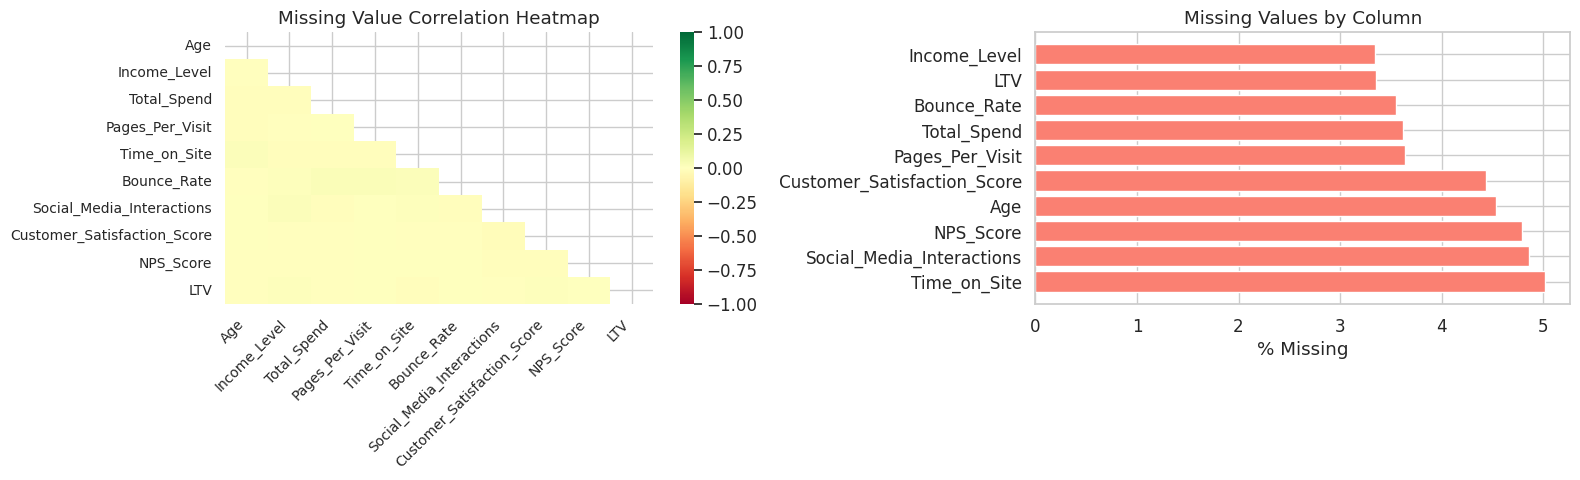

Time_on_Site                  5.017
Social_Media_Interactions     4.856
NPS_Score                     4.789
Age                           4.534
Customer_Satisfaction_Score   4.441
Pages_Per_Visit               3.636
Total_Spend                   3.622
Bounce_Rate                   3.555
LTV                           3.354
Income_Level                  3.340
dtype: float64


In [14]:
# ── B4. Missing value pattern
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Heatmap
msno.heatmap(df, ax=axes[0], cmap='RdYlGn', fontsize=10)
axes[0].set_title('Missing Value Correlation Heatmap')

# Bar chart of % missing
miss = (df.isnull().mean()*100).sort_values(ascending=False)
miss = miss[miss > 0]
axes[1].barh(miss.index, miss.values, color='salmon')
axes[1].set_xlabel('% Missing')
axes[1].set_title('Missing Values by Column')
plt.tight_layout()
plt.show()
print(miss)

In [15]:
# ── B5. Impute missing values
# Numeric → median (robust to outliers)
num_cols_miss = ['Age','Total_Spend','Time_on_Site','Customer_Satisfaction_Score',
                 'NPS_Score','Social_Media_Interactions','LTV','Bounce_Rate','Pages_Per_Visit']
for col in num_cols_miss:
    med = df[col].median()
    df[col].fillna(med, inplace=True)
    print(f'{col:35s} filled with median = {med:.2f}')

# Categorical → mode
df['Income_Level'].fillna(df['Income_Level'].mode()[0], inplace=True)

print(f'\nRemaining nulls: {df.isnull().sum().sum()}')
# 💡 Try: KNNImputer from sklearn for smarter numeric imputation

Age                                 filled with median = 44.00
Total_Spend                         filled with median = 3035.86
Time_on_Site                        filled with median = 5.68
Customer_Satisfaction_Score         filled with median = 5.00
NPS_Score                           filled with median = 5.00
Social_Media_Interactions           filled with median = 509.00
LTV                                 filled with median = 881.61
Bounce_Rate                         filled with median = 55.18
Pages_Per_Visit                     filled with median = 6.44

Remaining nulls: 0


In [16]:
# ── B6. Outlier detection — IQR
def iqr_bounds(s):
    Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
    IQR = Q3 - Q1
    return Q1 - 1.5*IQR, Q3 + 1.5*IQR

outlier_report = []
for col in ['Total_Spend','Time_on_Site','Conversion_Value','Impressions']:
    lo, hi = iqr_bounds(df[col])
    n = ((df[col]<lo)|(df[col]>hi)).sum()
    outlier_report.append({'Column':col,'Lower':lo,'Upper':hi,'Outliers':n,'Pct':round(n/len(df)*100,2)})
display(pd.DataFrame(outlier_report))

,Column,Lower,Upper,Outliers,Pct
0,Total_Spend,-7407.671,15401.319,537,7.200
1,Time_on_Site,-10.269,23.841,435,5.840
2,Conversion_Value,0.000,0.000,611,8.200
3,Impressions,-24681.000,74235.000,0,0.000


In [17]:
# ── B7. Outlier detection — Z-score
from scipy.stats import zscore
z_cols = ['Total_Spend','Time_on_Site','Conversion_Value']
z_scores = df[z_cols].apply(zscore)
print('Z-score outliers (|z| > 3):')
print((z_scores.abs() > 3).sum())

Z-score outliers (|z| > 3):
Total_Spend         30
Time_on_Site        48
Conversion_Value    20
dtype: int64


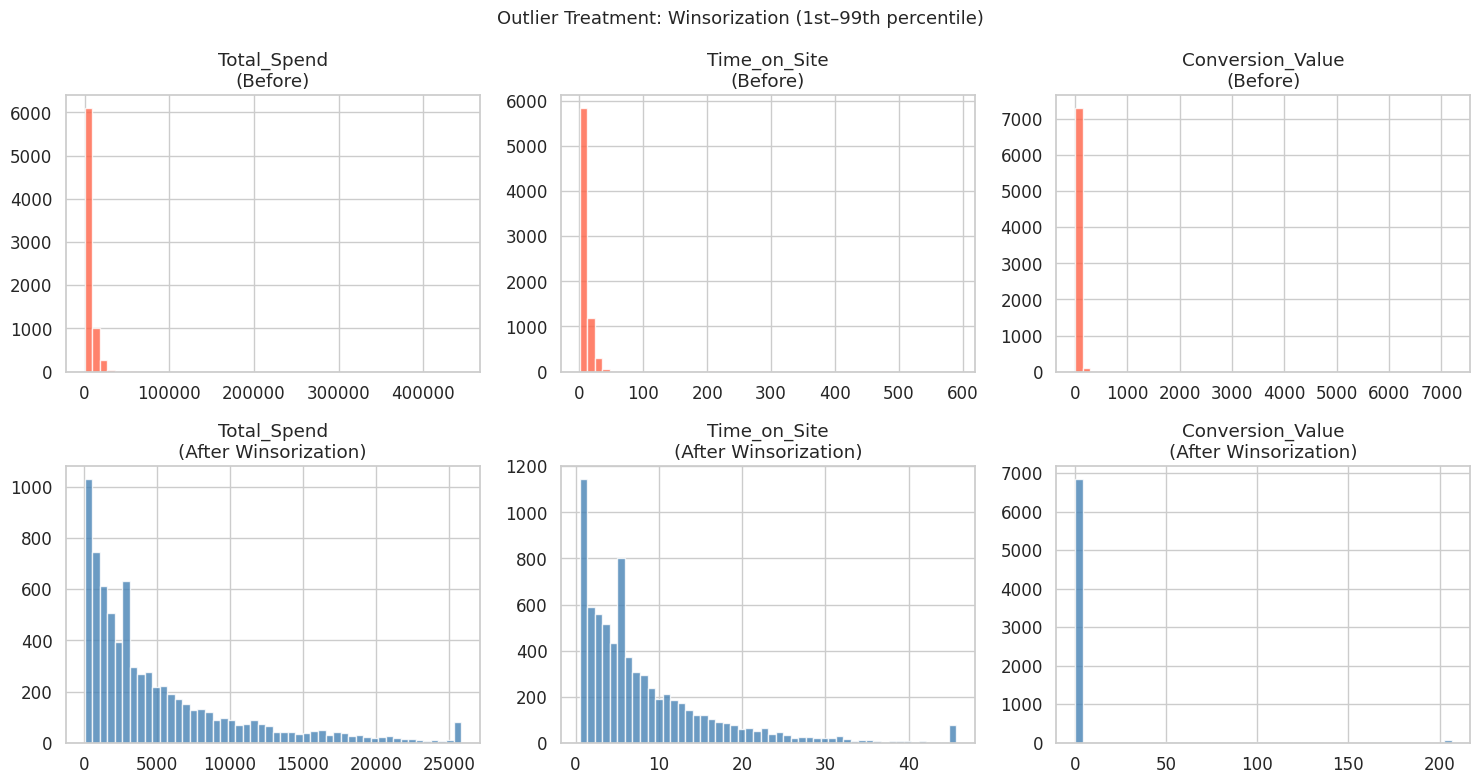

In [18]:
# ── B8. Visualise outliers — before/after winsorization
# Winsorization is a data cleaning technique used to handle extreme outliers in a dataset by capping them, rather than deleting them.

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
cols_to_cap = ['Total_Spend','Time_on_Site','Conversion_Value']

for i, col in enumerate(cols_to_cap):
    # Before
    axes[0][i].hist(df[col], bins=50, color='tomato', edgecolor='white', alpha=0.8)
    axes[0][i].set_title(f'{col}\n(Before)')

    # Winsorize
    lo, hi = df[col].quantile(0.01), df[col].quantile(0.99)
    df[col] = df[col].clip(lo, hi)

    # After
    axes[1][i].hist(df[col], bins=50, color='steelblue', edgecolor='white', alpha=0.8)
    axes[1][i].set_title(f'{col}\n(After Winsorization)')

plt.suptitle('Outlier Treatment: Winsorization (1st–99th percentile)', fontsize=13)
plt.tight_layout()
plt.show()

In [19]:
# ── B9. Feature engineering
# Revenue per click
df['Revenue_Per_Click'] = np.where(df['Clicks']>0, df['Conversion_Value']/df['Clicks'], 0).round(4)
# Engagement score (composite)
df['Engagement_Score'] = (
    (df['Pages_Per_Visit']/df['Pages_Per_Visit'].max()) * 0.3 +
    (df['Time_on_Site']/df['Time_on_Site'].max()) * 0.4 +
    (1 - df['Bounce_Rate']/100) * 0.3
).round(4)
# ROI
df['ROI'] = np.where(df['Total_Spend']>0,
                     (df['Conversion_Value'] - df['Total_Spend'])/df['Total_Spend'], 0).round(4)
# High value customer flag
df['High_Value_Flag'] = (df['LTV'] >= df['LTV'].quantile(0.75)).astype(int)

print('New features:', ['Revenue_Per_Click','Engagement_Score','ROI','High_Value_Flag'])
df[['Revenue_Per_Click','Engagement_Score','ROI','High_Value_Flag']].describe()

New features: ['Revenue_Per_Click', 'Engagement_Score', 'ROI', 'High_Value_Flag']


,Revenue_Per_Click,Engagement_Score,ROI,High_Value_Flag
count,7454.000,7454.000,7454.000,7454.000
mean,0.020,0.368,-0.989,0.250
std,0.352,0.122,0.118,0.433
min,0.000,0.075,-1.000,0.000
25%,0.000,0.283,-1.000,0.000
50%,0.000,0.361,-1.000,0.000
75%,0.000,0.444,-1.000,0.750
max,23.537,0.896,3.569,1.000


---
## Section C: Univariate Analysis

In [22]:
# ── C1. Numeric summary stats with skewness & kurtosis
num_cols = df.select_dtypes(include='number').columns.tolist()
stats_df = df[num_cols].agg(['mean','median','std','skew']).T
stats_df['kurtosis'] = df[num_cols].kurtosis()
stats_df['cv_%'] = (df[num_cols].std() / df[num_cols].mean() * 100).round(2)
display(stats_df.round(3))

# CV (Coefficient of Variation) = (STDEV/Mean)*100
# Standard deviation alone only tells you the spread in raw units
# (e.g., spending $5,000 vs. being 14 years apart). Because cv_% standardizes everything
# into a percentage, it gives you an apples-to-apples comparison of which business metrics
# are stable and which ones are unpredictable.

,mean,median,std,skew,kurtosis,cv_%
Month,6.640,7.000,3.457,-0.040,-1.215,52.060
Quarter,2.544,3.000,1.124,-0.051,-1.372,44.200
Age,44.126,44.000,14.837,-0.005,-1.095,33.620
Customer_Tenure,60.554,61.000,34.232,-0.019,-1.178,56.530
Impressions,24750.559,24296.000,14323.975,0.045,-1.177,57.870
Clicks,1966.479,1534.500,1611.051,0.936,0.119,81.930
CTR,0.080,0.079,0.040,0.028,-1.198,50.700
Cost_per_Click,2.577,2.580,1.418,-0.018,-1.217,55.050
Total_Spend,5043.706,3035.860,5492.972,1.720,2.720,108.910
Website_Visits,250.071,249.000,144.175,-0.010,-1.198,57.650


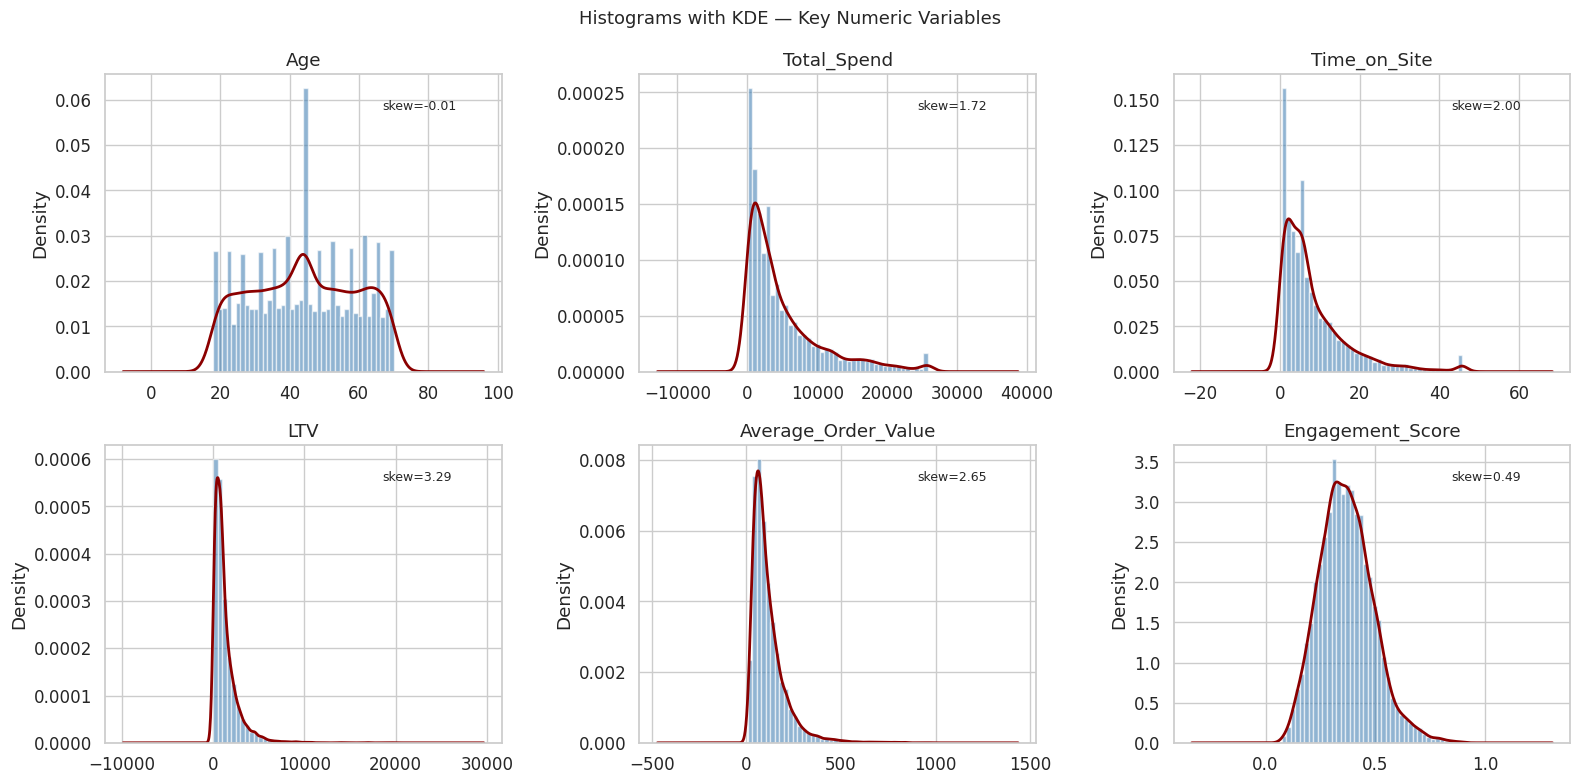

In [23]:
# ── C2. Histograms + KDE (Kernel Density Estimation) for key numeric cols
key_num = ['Age','Total_Spend','Time_on_Site','LTV','Average_Order_Value','Engagement_Score']
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flat, key_num):
    df[col].hist(bins=40, density=True, alpha=0.6, color='steelblue', edgecolor='white', ax=ax)
    df[col].plot.kde(ax=ax, color='darkred', linewidth=2)
    ax.set_title(col)
    ax.set_ylabel('Density')
    skew = df[col].skew()
    ax.annotate(f'skew={skew:.2f}', xy=(0.7,0.88), xycoords='axes fraction', fontsize=9)
plt.suptitle('Histograms with KDE — Key Numeric Variables', fontsize=13)
plt.tight_layout()
plt.show()

# It is a way to estimate and plot the probability density function of a continuous variable.
# In plain English, a KDE plot is a smoothed version of a histogram.

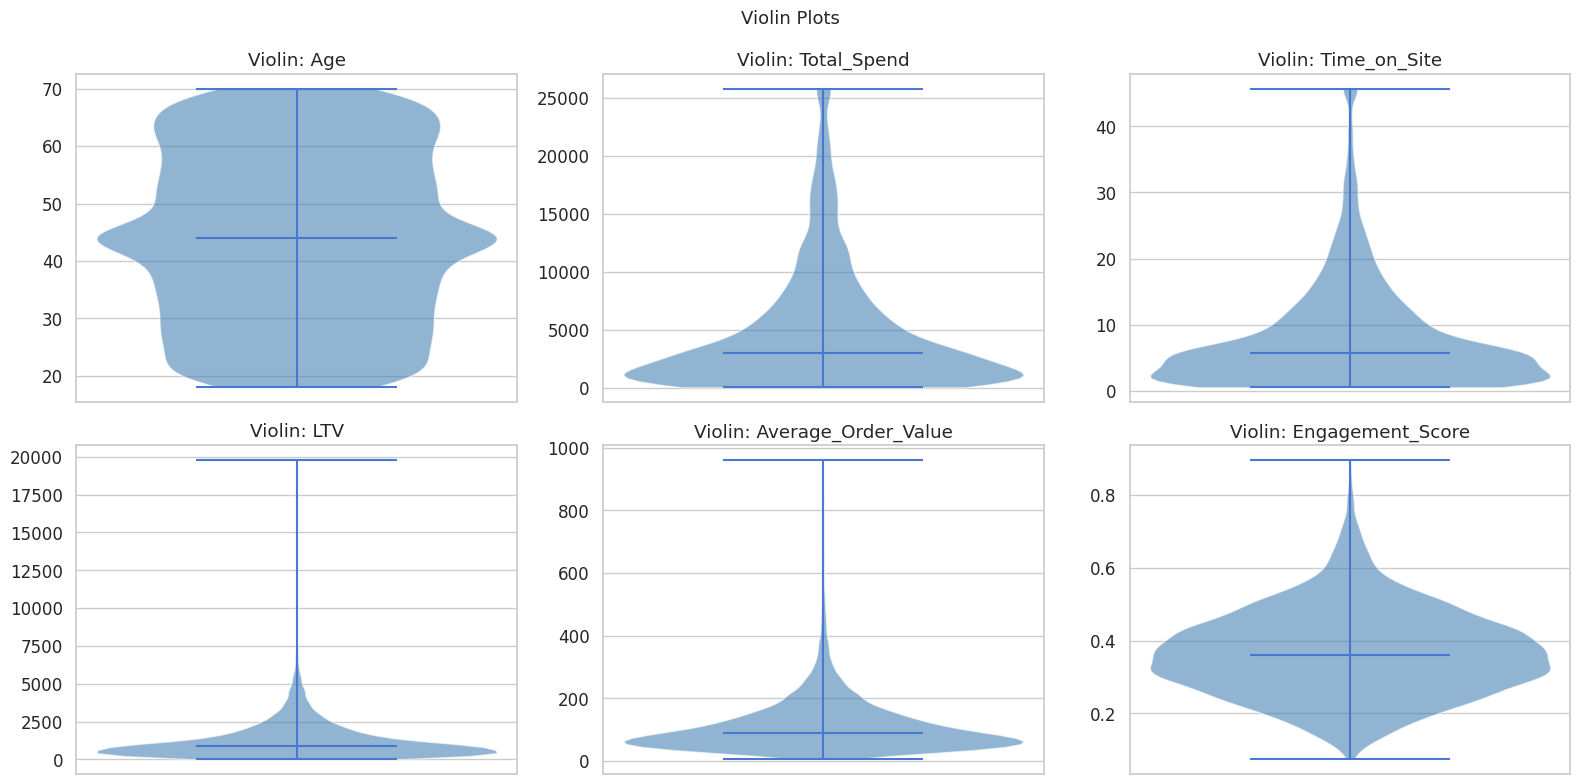

In [24]:
# ── C3. Box plots + violin plots
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flat, key_num):
    parts = ax.violinplot(df[col].dropna(), showmedians=True)
    for pc in parts['bodies']:
        pc.set_facecolor('steelblue')
        pc.set_alpha(0.6)
    ax.set_title(f'Violin: {col}')
    ax.set_xticks([])
plt.suptitle('Violin Plots', fontsize=13)
plt.tight_layout()
plt.show()

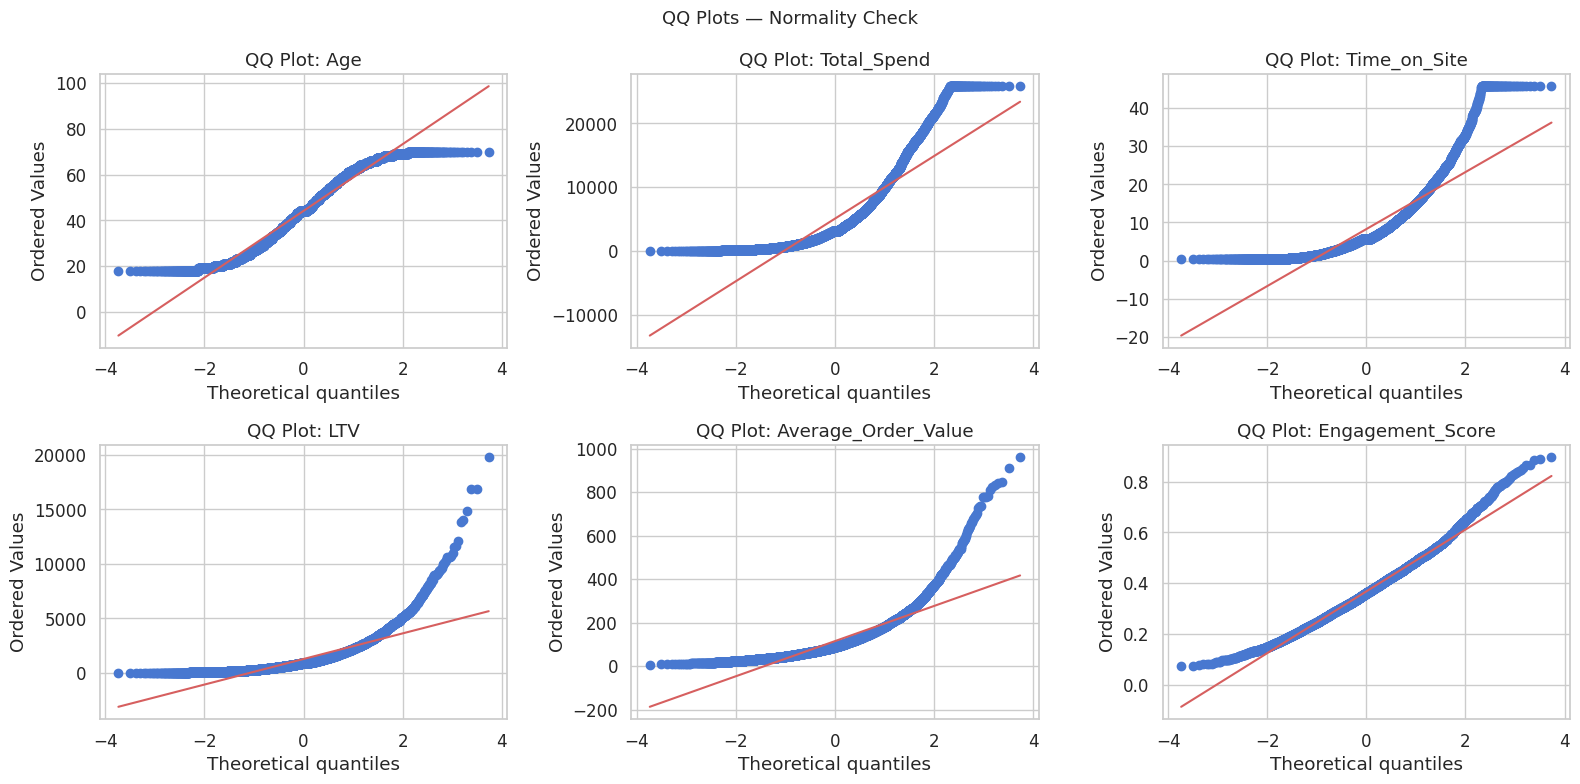

In [25]:
# ── C4. QQ plots for normality check
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flat, key_num):
    stats.probplot(df[col].dropna(), dist='norm', plot=ax)
    ax.set_title(f'QQ Plot: {col}')
plt.suptitle('QQ Plots — Normality Check', fontsize=13)
plt.tight_layout()
plt.show()

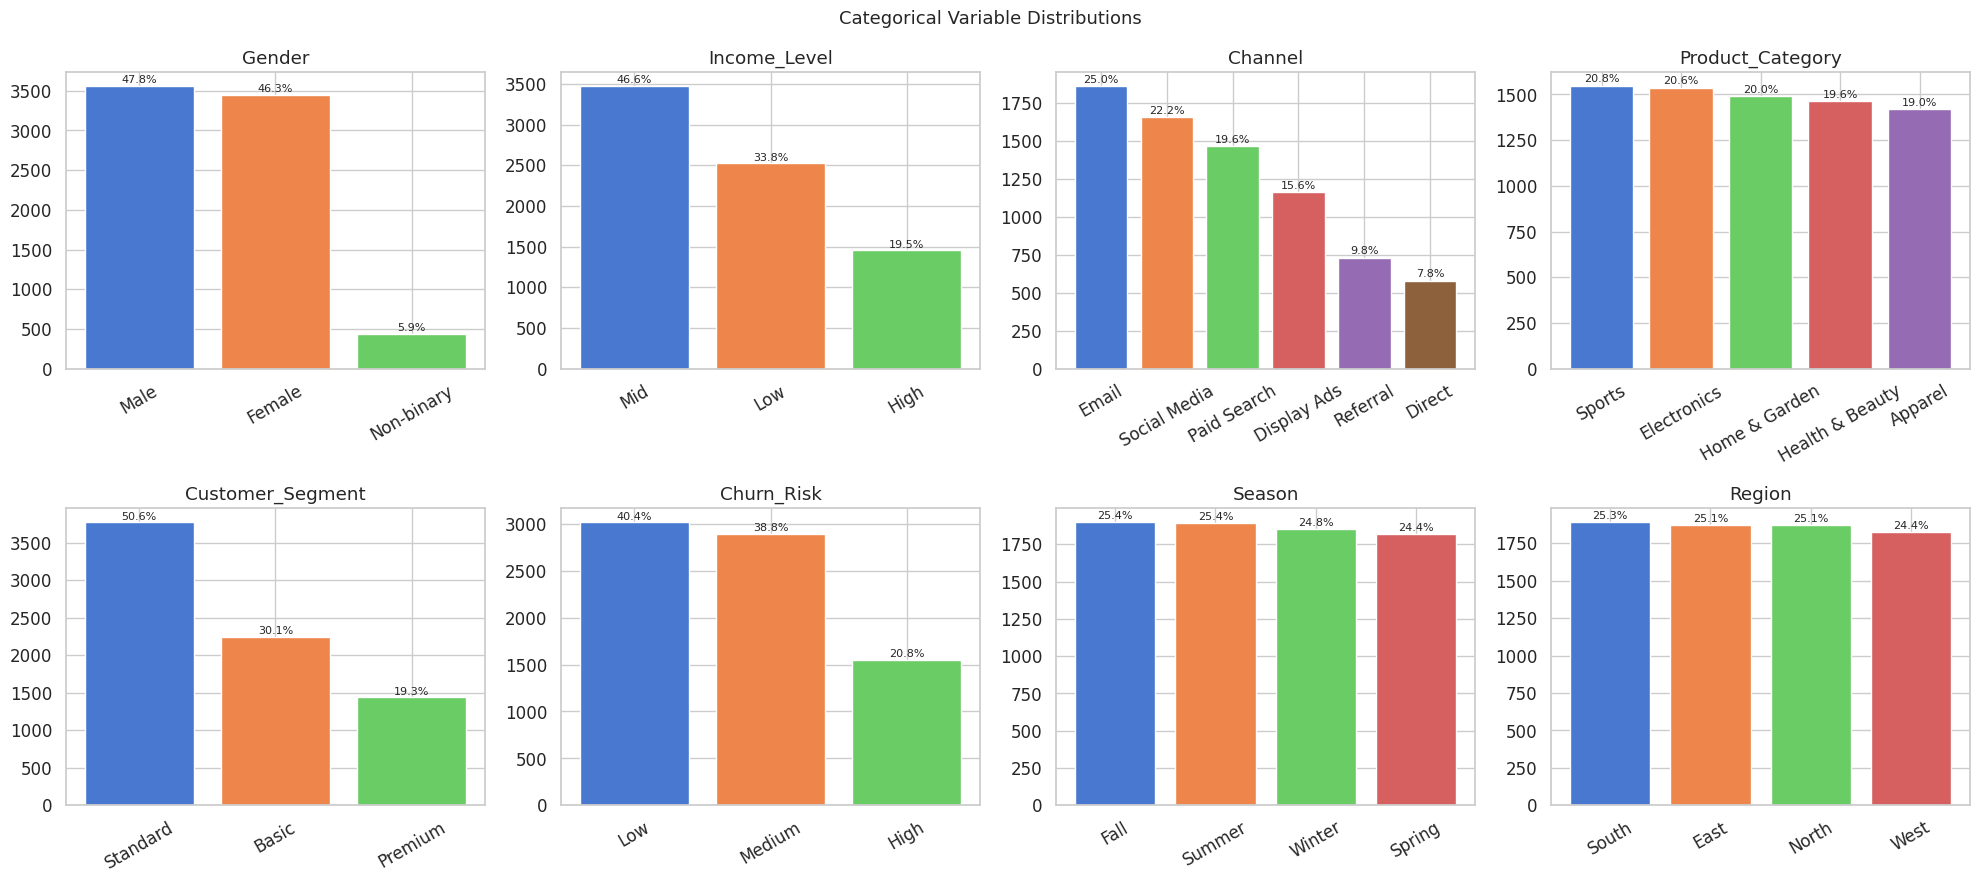

In [26]:
# ── C5. Categorical frequency tables & bar charts
cat_cols = ['Gender','Income_Level','Channel','Product_Category',
            'Customer_Segment','Churn_Risk','Season','Region']
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
for ax, col in zip(axes.flat, cat_cols):
    vc = df[col].value_counts()
    bars = ax.bar(vc.index, vc.values, color=sns.color_palette('muted', len(vc)))
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=30)
    # Add % labels
    total = vc.sum()
    for bar, val in zip(bars, vc.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+10,
                f'{val/total*100:.1f}%', ha='center', va='bottom', fontsize=8)
plt.suptitle('Categorical Variable Distributions', fontsize=13)
plt.tight_layout()
plt.show()

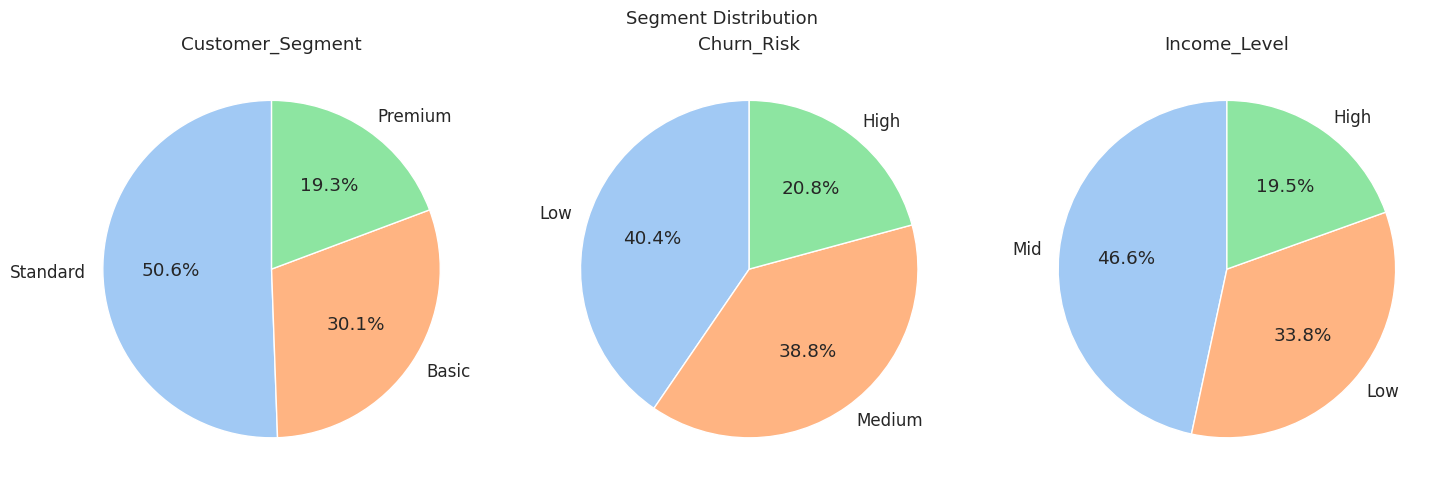

In [27]:
# ── C6. Pie charts for top-level segments
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, col in zip(axes, ['Customer_Segment','Churn_Risk','Income_Level']):
    vc = df[col].value_counts()
    ax.pie(vc.values, labels=vc.index, autopct='%1.1f%%', startangle=90,
           colors=sns.color_palette('pastel', len(vc)))
    ax.set_title(col)
plt.suptitle('Segment Distribution', fontsize=13)
plt.tight_layout()
plt.show()

---
## Section D: Bivariate Analysis

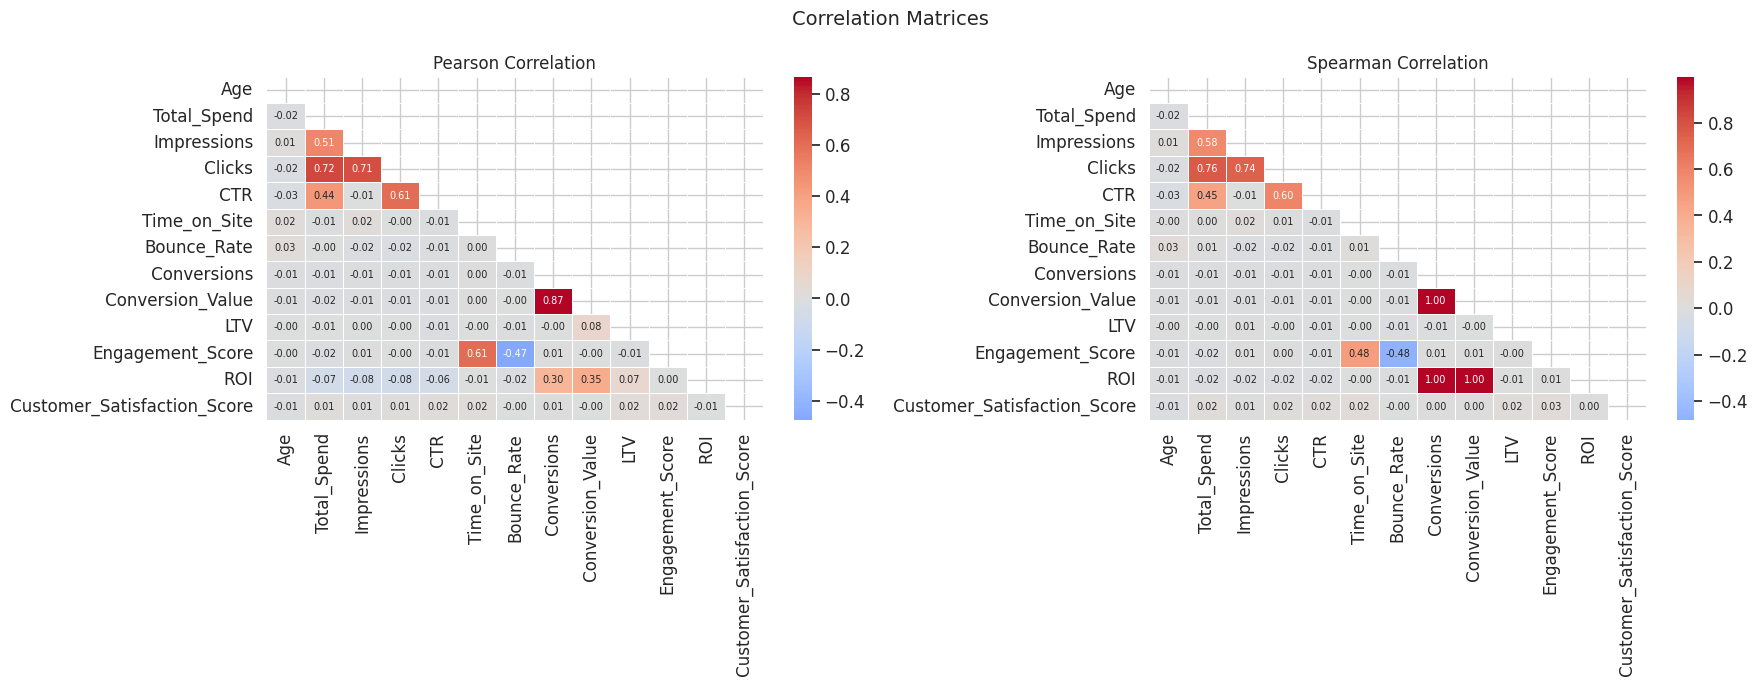

In [28]:
# ── D1. Pearson & Spearman correlation matrices
corr_num = ['Age','Total_Spend','Impressions','Clicks','CTR','Time_on_Site',
            'Bounce_Rate','Conversions','Conversion_Value','LTV',
            'Engagement_Score','ROI','Customer_Satisfaction_Score']

pearson  = df[corr_num].corr(method='pearson')
spearman = df[corr_num].corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, mat, title in zip(axes, [pearson, spearman], ['Pearson','Spearman']):
    mask = np.triu(np.ones_like(mat, dtype=bool))
    sns.heatmap(mat, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
                center=0, linewidths=0.4, annot_kws={'size':7}, ax=ax)
    ax.set_title(f'{title} Correlation', fontsize=12)
plt.suptitle('Correlation Matrices', fontsize=14)
plt.tight_layout()
plt.show()

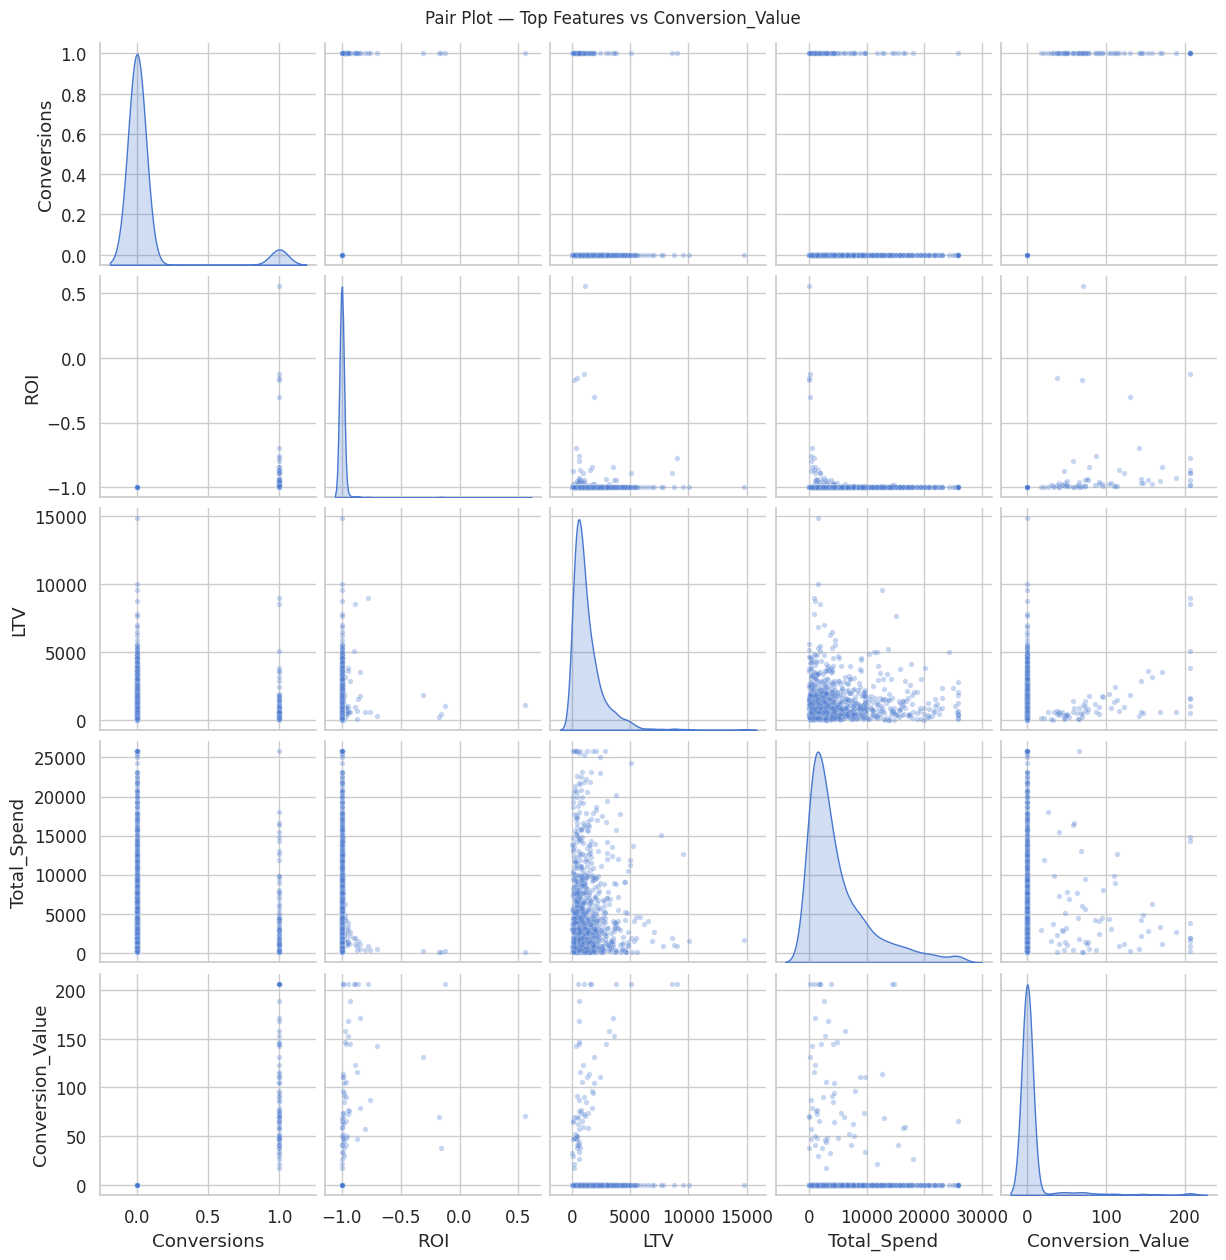

In [29]:
# ── D2. Pair plot — top 5 features correlated with Conversion_Value
top5 = pearson['Conversion_Value'].abs().drop('Conversion_Value').nlargest(4).index.tolist()
top5.append('Conversion_Value')
pp = sns.pairplot(df[top5].sample(1000, random_state=1),
                  diag_kind='kde', plot_kws={'alpha':0.3, 's':15},
                  diag_kws={'fill':True})
pp.fig.suptitle('Pair Plot — Top Features vs Conversion_Value', y=1.01, fontsize=12)
plt.show()

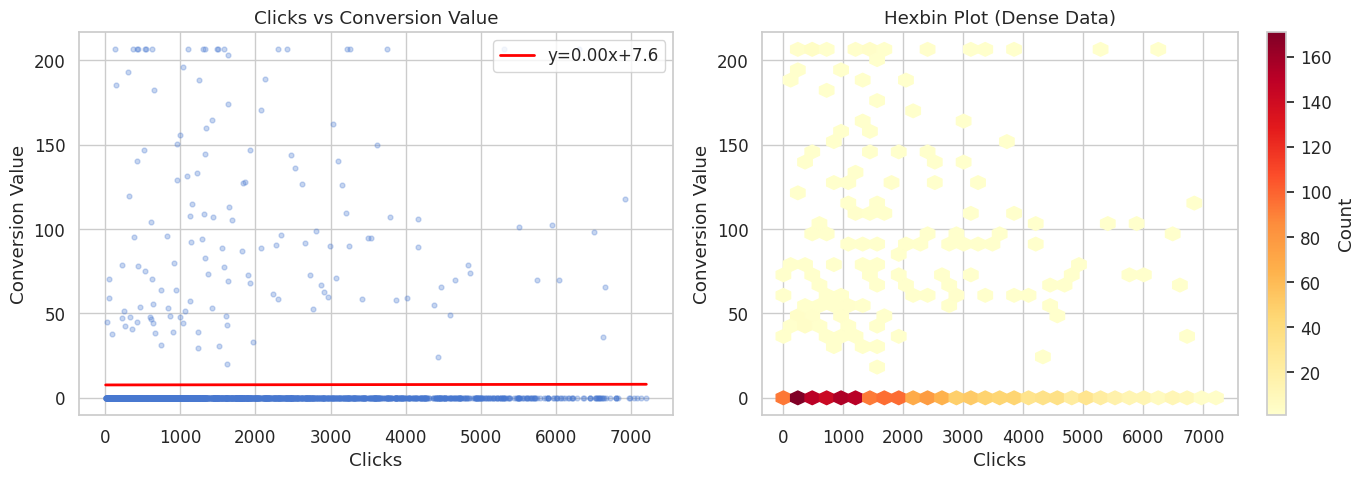

In [30]:
# ── D3. Scatter + regression: Clicks vs Conversion_Value
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sample = df.sample(2000, random_state=42)

# Regular scatter
axes[0].scatter(sample['Clicks'], sample['Conversion_Value'], alpha=0.3, s=12)
m, b = np.polyfit(sample['Clicks'], sample['Conversion_Value'], 1)
x_line = np.linspace(sample['Clicks'].min(), sample['Clicks'].max(), 100)
axes[0].plot(x_line, m*x_line+b, color='red', linewidth=2, label=f'y={m:.2f}x+{b:.1f}')
axes[0].set_xlabel('Clicks'); axes[0].set_ylabel('Conversion Value')
axes[0].set_title('Clicks vs Conversion Value')
axes[0].legend()

# Hexbin for dense data
axes[1].hexbin(sample['Clicks'], sample['Conversion_Value'],
               gridsize=30, cmap='YlOrRd', mincnt=1)
axes[1].set_xlabel('Clicks'); axes[1].set_ylabel('Conversion Value')
axes[1].set_title('Hexbin Plot (Dense Data)')
plt.colorbar(axes[1].collections[0], ax=axes[1], label='Count')
plt.tight_layout()
plt.show()

Chi-square: χ²=79.44, p=0.0000, dof=5
Reject H₀ (independent)


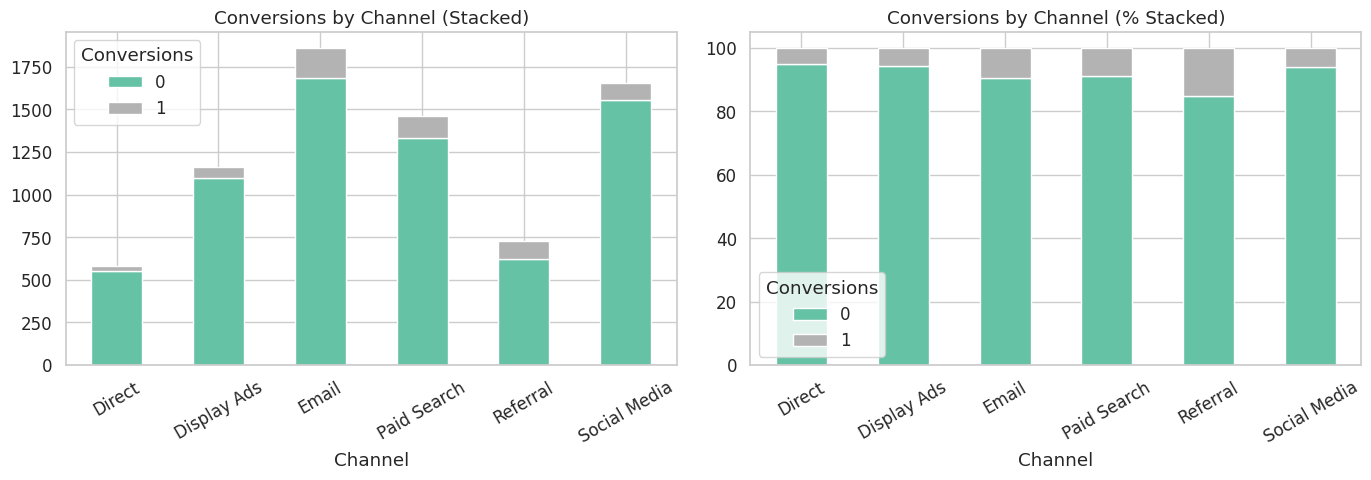

In [31]:
# ── D4. Categorical vs Categorical: Chi-square test
# Channel vs Conversions
ct = pd.crosstab(df['Channel'], df['Conversions'])
chi2, p, dof, expected = chi2_contingency(ct)
print(f'Chi-square: χ²={chi2:.2f}, p={p:.4f}, dof={dof}')
print('Reject H₀ (independent)' if p < 0.05 else 'Fail to reject H₀')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ct.plot(kind='bar', stacked=True, ax=axes[0], colormap='Set2')
axes[0].set_title('Conversions by Channel (Stacked)')
axes[0].tick_params(axis='x', rotation=30)

ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
ct_pct.plot(kind='bar', stacked=True, ax=axes[1], colormap='Set2')
axes[1].set_title('Conversions by Channel (% Stacked)')
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

One-way ANOVA — LTV by Segment: F=0.75, p=0.4740


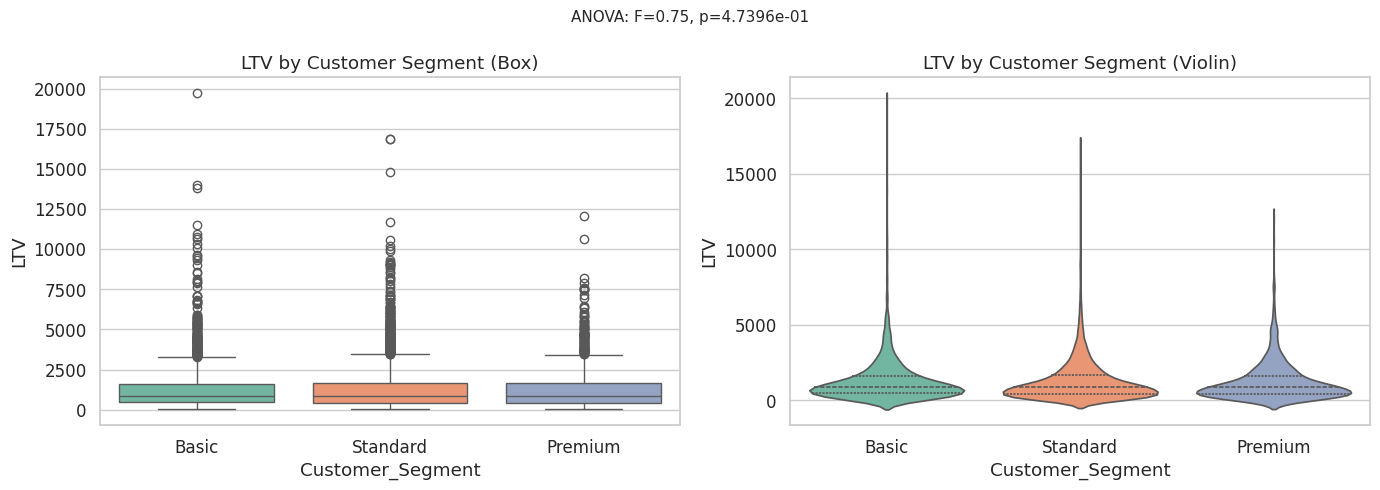

In [32]:
# ── D5. Categorical vs Numerical: ANOVA + grouped box/violin
# LTV across Customer Segments
groups = [grp['LTV'].values for _, grp in df.groupby('Customer_Segment')]
f_stat, p_anova = stats.f_oneway(*groups)
print(f'One-way ANOVA — LTV by Segment: F={f_stat:.2f}, p={p_anova:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df, x='Customer_Segment', y='LTV', palette='Set2', ax=axes[0])
axes[0].set_title('LTV by Customer Segment (Box)')

sns.violinplot(data=df, x='Customer_Segment', y='LTV', palette='Set2',
               inner='quartile', ax=axes[1])
axes[1].set_title('LTV by Customer Segment (Violin)')
plt.suptitle(f'ANOVA: F={f_stat:.2f}, p={p_anova:.4e}', fontsize=11)
plt.tight_layout()
plt.show()

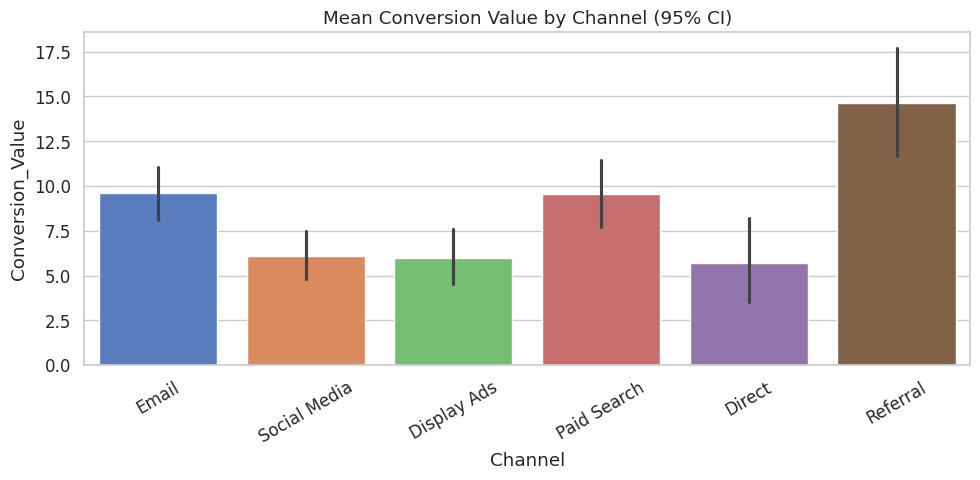

In [33]:
# ── D6. Bar plot of means with CI
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=df, x='Channel', y='Conversion_Value',
            estimator=np.mean, ci=95, palette='muted', ax=ax)
ax.set_title('Mean Conversion Value by Channel (95% CI)')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

In [34]:
# ── D7. T-test: Male vs Female Conversion Value
male   = df[df['Gender']=='Male']['Conversion_Value']
female = df[df['Gender']=='Female']['Conversion_Value']
t_stat, p_ttest = stats.ttest_ind(male, female, equal_var=False)  # Welch's
print(f"Welch's t-test — Male vs Female Conversion Value:")
print(f'  t={t_stat:.3f}, p={p_ttest:.4f}')
print('  Significant difference' if p_ttest<0.05 else '  No significant difference')

Welch's t-test — Male vs Female Conversion Value:
  t=0.438, p=0.6611
  No significant difference


---
## Section E: Multivariate Analysis

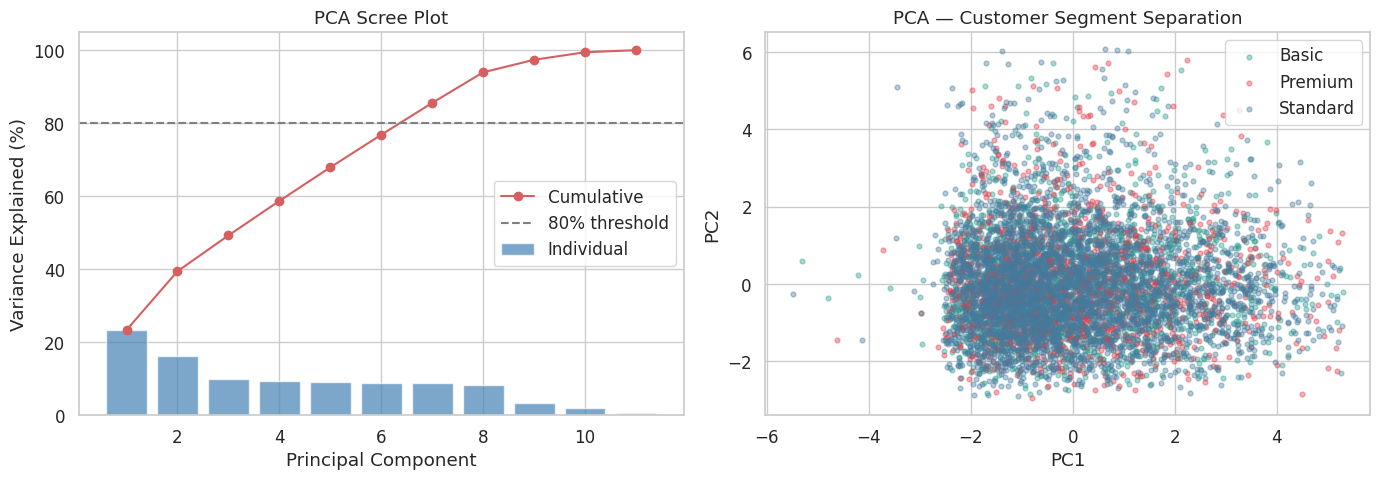

In [35]:
# ── E1. PCA (Principal Component Analysis)
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

pca_cols = ['Age','Total_Spend','Impressions','Clicks','CTR','Time_on_Site',
            'Bounce_Rate','LTV','Engagement_Score','Customer_Satisfaction_Score','ROI']
X_pca = df[pca_cols].dropna()
X_scaled = StandardScaler().fit_transform(X_pca)

pca = PCA(n_components=len(pca_cols))
pca.fit(X_scaled)

# Scree plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
var_exp = pca.explained_variance_ratio_ * 100
cum_var = np.cumsum(var_exp)
axes[0].bar(range(1,len(var_exp)+1), var_exp, color='steelblue', alpha=0.7, label='Individual')
axes[0].plot(range(1,len(var_exp)+1), cum_var, 'ro-', label='Cumulative')
axes[0].axhline(80, color='gray', linestyle='--', label='80% threshold')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Variance Explained (%)')
axes[0].set_title('PCA Scree Plot')
axes[0].legend()

# 2D PCA scatter coloured by Customer Segment
pca2d = PCA(n_components=2).fit_transform(X_scaled)
seg_labels = df.loc[X_pca.index, 'Customer_Segment']
colors = {'Premium':'#e63946','Standard':'#457b9d','Basic':'#2a9d8f'}
for seg, grp_idx in seg_labels.groupby(seg_labels).groups.items():
    mask = seg_labels == seg
    axes[1].scatter(pca2d[mask,0], pca2d[mask,1], label=seg,
                    alpha=0.4, s=12, color=colors.get(seg,'gray'))
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')
axes[1].set_title('PCA — Customer Segment Separation')
axes[1].legend()
plt.tight_layout()
plt.show()

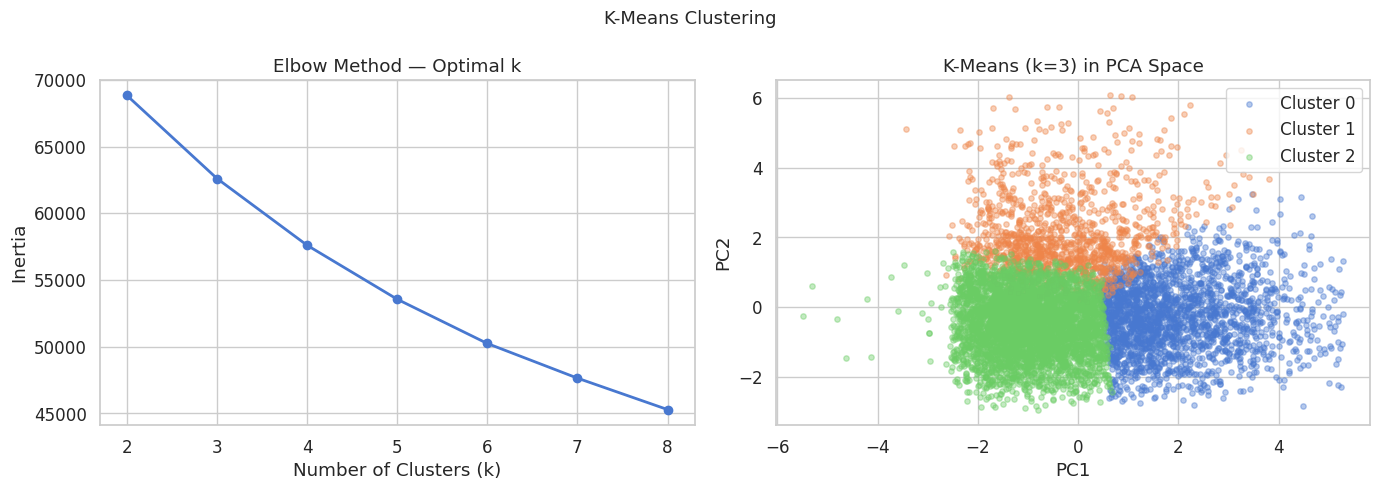

Cluster means:


,LTV,Total_Spend,Conversion_Value,Engagement_Score
Cluster,,,,
0,1262.500,10872.950,7.430,0.350
1,1273.650,3823.100,8.090,0.540
2,1298.910,2325.380,9.060,0.330


In [36]:
# ── E2. K-Means Clustering
from sklearn.cluster import KMeans

# Elbow method
inertia = []
K = range(2, 9)
for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(K, inertia, 'bo-', linewidth=2)
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method — Optimal k')

# Fit k=3 and visualise on PCA space
km3 = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels = km3.fit_predict(X_scaled)
for c in range(3):
    mask = cluster_labels == c
    axes[1].scatter(pca2d[mask,0], pca2d[mask,1], label=f'Cluster {c}',
                    alpha=0.4, s=15)
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')
axes[1].set_title('K-Means (k=3) in PCA Space')
axes[1].legend()
plt.suptitle('K-Means Clustering', fontsize=13)
plt.tight_layout()
plt.show()

df_pca = df.loc[X_pca.index].copy()
df_pca['Cluster'] = cluster_labels
print('Cluster means:')
display(df_pca.groupby('Cluster')[['LTV','Total_Spend','Conversion_Value','Engagement_Score']].mean().round(2))

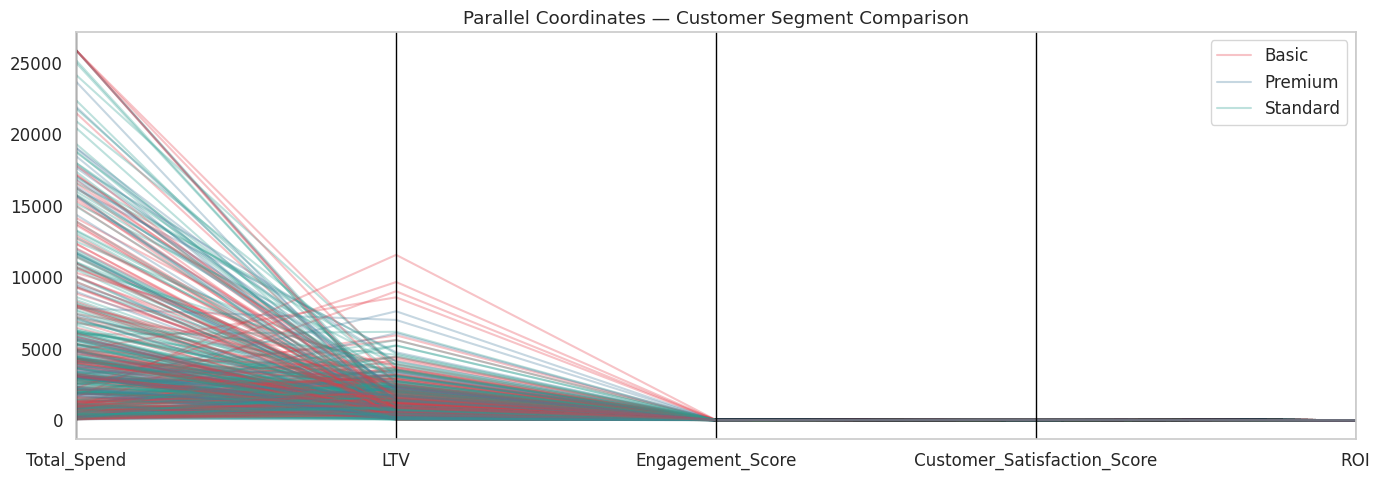

In [37]:
# ── E3. Parallel coordinates — segment comparison
from pandas.plotting import parallel_coordinates
pc_cols = ['Customer_Segment','Total_Spend','LTV','Engagement_Score',
           'Customer_Satisfaction_Score','ROI']
sample_pc = df[pc_cols].sample(500, random_state=42).copy()
fig, ax = plt.subplots(figsize=(14, 5))
parallel_coordinates(sample_pc, 'Customer_Segment',
                     color=['#e63946','#457b9d','#2a9d8f'], alpha=0.3, ax=ax)
ax.set_title('Parallel Coordinates — Customer Segment Comparison')
plt.tight_layout()
plt.show()

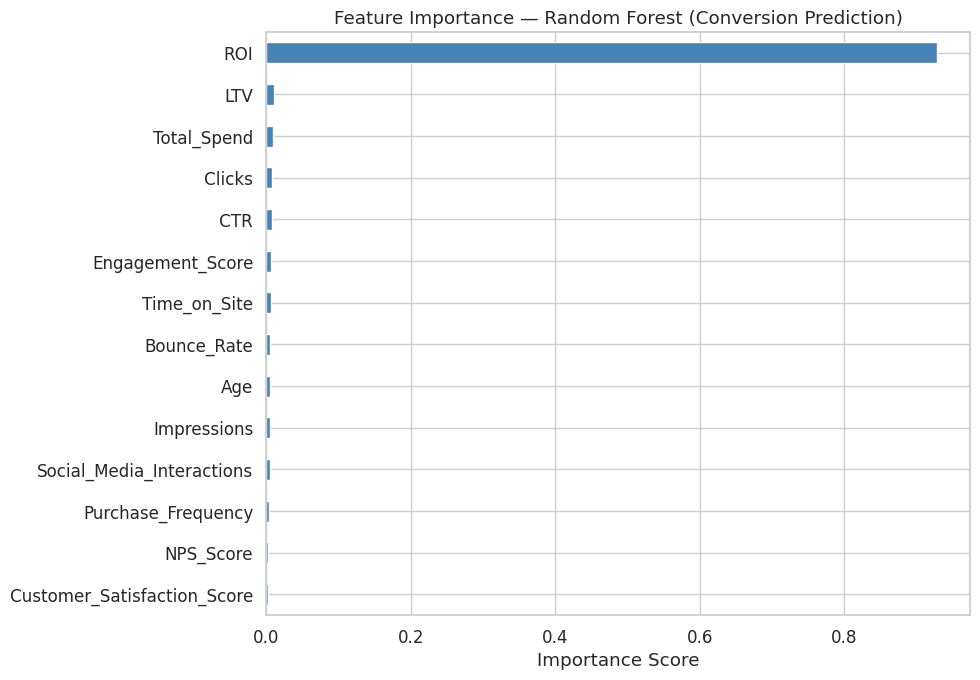

In [38]:
# ── E4. Feature importance — Random Forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

feat_cols = ['Age','Total_Spend','Impressions','Clicks','CTR','Time_on_Site',
             'Bounce_Rate','LTV','Engagement_Score','Customer_Satisfaction_Score',
             'NPS_Score','Social_Media_Interactions','Purchase_Frequency','ROI']
X_fi = df[feat_cols].fillna(0)
y_fi = (df['Conversion_Value'] > 0).astype(int)

rf = RandomForestClassifier(n_estimators=150, max_depth=6, random_state=42, n_jobs=-1)
rf.fit(X_fi, y_fi)

importances = pd.Series(rf.feature_importances_, index=feat_cols).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(10, 7))
importances.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Feature Importance — Random Forest (Conversion Prediction)')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [39]:
# ── E5. 3D Scatter (Plotly interactive)
fig_3d = px.scatter_3d(
    df.sample(1500, random_state=42),
    x='Total_Spend', y='LTV', z='Conversion_Value',
    color='Customer_Segment',
    size='Engagement_Score',
    opacity=0.6,
    title='3D: Total Spend vs LTV vs Conversion Value by Segment'
)
fig_3d.update_traces(marker=dict(sizemode='area', sizeref=0.05))
fig_3d.show()

---
## Section F: Time Series Analysis

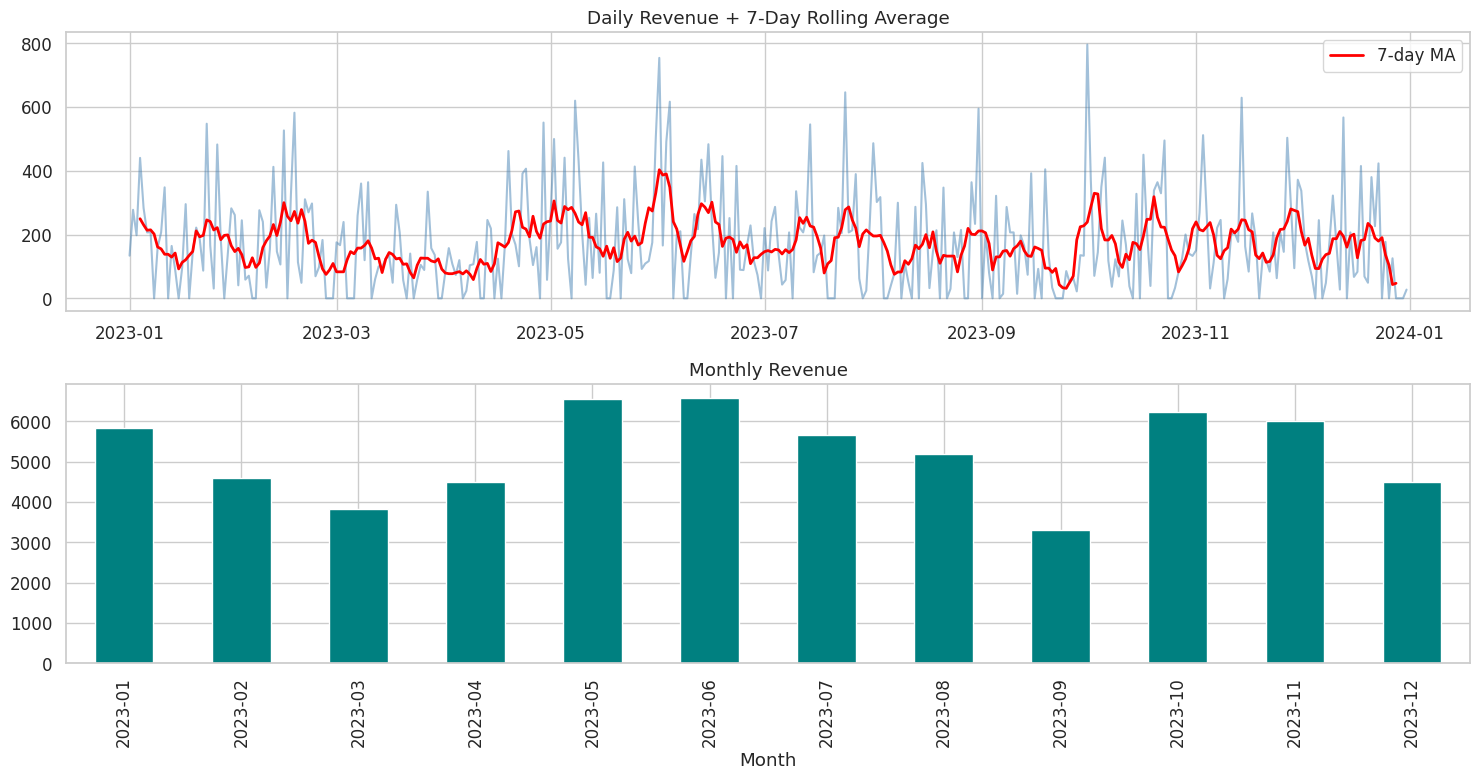

In [40]:
# ── F1. Daily & Monthly revenue trend
daily   = df.groupby('Date')['Conversion_Value'].sum().reset_index()
monthly = df.groupby(df['Date'].dt.to_period('M'))['Conversion_Value'].sum()

fig, axes = plt.subplots(2, 1, figsize=(15, 8))
axes[0].plot(daily['Date'], daily['Conversion_Value'], alpha=0.5, color='steelblue')
axes[0].plot(daily['Date'],
             daily['Conversion_Value'].rolling(7, center=True).mean(),
             color='red', linewidth=2, label='7-day MA')
axes[0].set_title('Daily Revenue + 7-Day Rolling Average')
axes[0].legend()

monthly.plot(kind='bar', ax=axes[1], color='teal', edgecolor='white')
axes[1].set_title('Monthly Revenue')
axes[1].set_xlabel('Month')
plt.tight_layout()
plt.show()

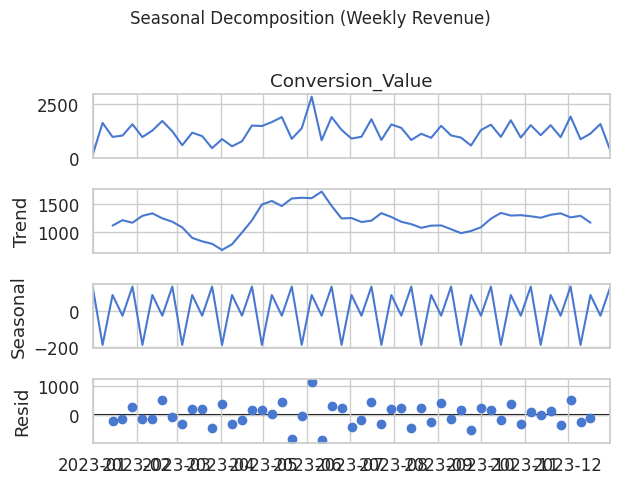

In [41]:
# ── F2. Seasonal decomposition
ts = daily.set_index('Date')['Conversion_Value'].resample('W').sum()
result = seasonal_decompose(ts, model='additive', period=4)
result.plot()
plt.suptitle('Seasonal Decomposition (Weekly Revenue)', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

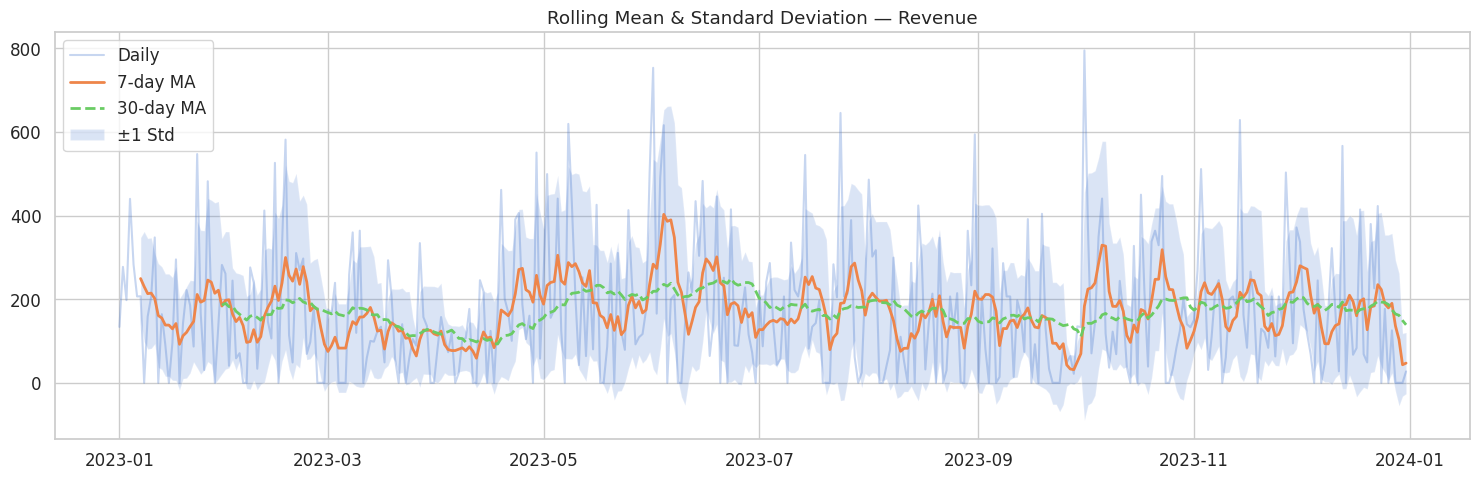

In [42]:
# ── F3. Rolling statistics
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(daily['Date'], daily['Conversion_Value'], alpha=0.3, label='Daily')
ax.plot(daily['Date'], daily['Conversion_Value'].rolling(7).mean(), label='7-day MA', linewidth=2)
ax.plot(daily['Date'], daily['Conversion_Value'].rolling(30).mean(), label='30-day MA', linewidth=2, linestyle='--')
rolling_std = daily['Conversion_Value'].rolling(7).std()
ax.fill_between(daily['Date'],
                daily['Conversion_Value'].rolling(7).mean() - rolling_std,
                daily['Conversion_Value'].rolling(7).mean() + rolling_std,
                alpha=0.2, label='±1 Std')
ax.legend()
ax.set_title('Rolling Mean & Standard Deviation — Revenue')
plt.tight_layout()
plt.show()

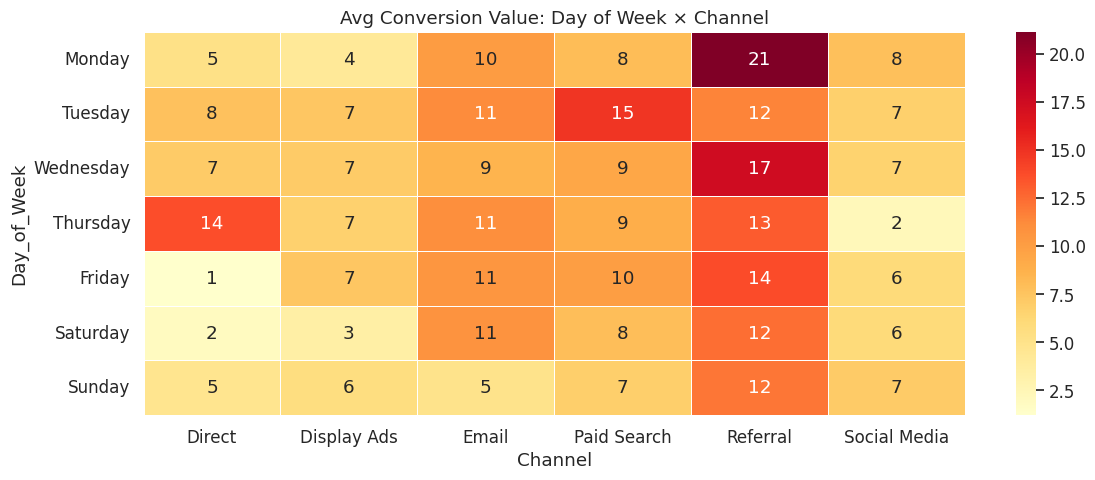

In [43]:
# ── F4. Day-of-week & seasonality heatmap
df['Week'] = df['Date'].dt.isocalendar().week.astype(int)
pivot = df.groupby(['Day_of_Week','Channel'])['Conversion_Value'].mean().unstack()
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
pivot = pivot.reindex([d for d in day_order if d in pivot.index])
fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd', linewidths=0.4, ax=ax)
ax.set_title('Avg Conversion Value: Day of Week × Channel')
plt.tight_layout()
plt.show()

---
## Section G: Advanced Interactive Visualizations (Plotly)

In [44]:
# ── G1. Interactive dashboard: Channel performance
channel_perf = df.groupby('Channel').agg(
    Total_Spend   = ('Total_Spend','sum'),
    Total_Revenue = ('Conversion_Value','sum'),
    Conversions   = ('Conversions','sum'),
    Avg_LTV       = ('LTV','mean')
).reset_index()
channel_perf['ROI_Pct'] = ((channel_perf.Total_Revenue - channel_perf.Total_Spend)
                            / channel_perf.Total_Spend * 100).round(2)

fig = make_subplots(rows=1, cols=2,
                    subplot_titles=['Spend vs Revenue by Channel','ROI % by Channel'])
fig.add_trace(go.Bar(name='Spend', x=channel_perf.Channel, y=channel_perf.Total_Spend,
                     marker_color='salmon'), row=1, col=1)
fig.add_trace(go.Bar(name='Revenue', x=channel_perf.Channel, y=channel_perf.Total_Revenue,
                     marker_color='steelblue'), row=1, col=1)
fig.add_trace(go.Bar(x=channel_perf.Channel, y=channel_perf.ROI_Pct,
                     marker_color='teal', name='ROI%'), row=1, col=2)
fig.update_layout(title='Channel Performance Dashboard', barmode='group', height=450)
fig.show()

In [45]:
# ── G2. Sunburst chart — hierarchical revenue breakdown
sunburst_df = df.groupby(['Region','Customer_Segment','Channel'])['Conversion_Value'].sum().reset_index()
fig_sun = px.sunburst(sunburst_df,
                      path=['Region','Customer_Segment','Channel'],
                      values='Conversion_Value',
                      title='Revenue Hierarchy: Region → Segment → Channel')
fig_sun.show()

In [46]:
# ── G3. Animated scatter — monthly trends
anim_df = df.groupby(['Month','Channel']).agg(
    Spend   = ('Total_Spend','sum'),
    Revenue = ('Conversion_Value','sum'),
    Clicks  = ('Clicks','sum')
).reset_index()
fig_anim = px.scatter(anim_df, x='Spend', y='Revenue', animation_frame='Month',
                      color='Channel', size='Clicks', size_max=60,
                      title='Monthly: Spend vs Revenue by Channel (animated)')
fig_anim.show()

In [47]:
# ── G4. Plotly box plots with dropdown
# Interactive: choose metric to compare across segments
metrics = ['LTV','Total_Spend','Engagement_Score','ROI','Customer_Satisfaction_Score']
fig_box = go.Figure()
for i, metric in enumerate(metrics):
    for seg in df['Customer_Segment'].unique():
        fig_box.add_trace(go.Box(
            y=df[df['Customer_Segment']==seg][metric],
            name=seg, visible=(i==0),
            marker_color={'Premium':'#e63946','Standard':'#457b9d','Basic':'#2a9d8f'}.get(seg)
        ))
buttons = []
n_segs = df['Customer_Segment'].nunique()
for i, metric in enumerate(metrics):
    visible = [False] * (len(metrics) * n_segs)
    for j in range(n_segs):
        visible[i*n_segs + j] = True
    buttons.append(dict(label=metric, method='update',
                        args=[{'visible':visible},{'title':f'{metric} by Segment'}]))
fig_box.update_layout(
    updatemenus=[dict(buttons=buttons, direction='down', x=0.1, y=1.15)],
    title='Metric Comparison by Segment (use dropdown)',
    height=500
)
fig_box.show()

---
## Section H: Statistical Testing

In [48]:
# ── H1. Shapiro-Wilk normality test (on sample ≤5000)
print('Shapiro-Wilk Normality Test (H₀: data is normal)\n')
test_cols = ['Age','LTV','Total_Spend','Engagement_Score']
for col in test_cols:
    sample = df[col].dropna().sample(min(4999,len(df)), random_state=42)
    stat, p = shapiro(sample)
    verdict = 'NOT normal' if p < 0.05 else 'Normal'
    print(f'{col:35s}  W={stat:.4f}, p={p:.4e}  →  {verdict}')

Shapiro-Wilk Normality Test (H₀: data is normal)

Age                                  W=0.9609, p=1.0220e-34  →  NOT normal
LTV                                  W=0.7138, p=1.5140e-68  →  NOT normal
Total_Spend                          W=0.7944, p=4.1930e-62  →  NOT normal
Engagement_Score                     W=0.9870, p=4.2488e-21  →  NOT normal


In [49]:
# ── H2. Levene's test — variance homogeneity
print('Levene Test (H₀: equal variances)\n')
groups_ltv = [g['LTV'].values for _, g in df.groupby('Customer_Segment')]
stat, p = levene(*groups_ltv)
print(f'LTV across Segments: W={stat:.4f}, p={p:.4f}')
print('Variances significantly differ' if p<0.05 else 'Variances not significantly different')

Levene Test (H₀: equal variances)

LTV across Segments: W=0.2476, p=0.7806
Variances not significantly different


In [50]:
# ── H3. Mann-Whitney U (non-parametric alternative to t-test)
high_seg = df[df['Customer_Segment']=='Premium']['Conversion_Value']
std_seg  = df[df['Customer_Segment']=='Standard']['Conversion_Value']
u_stat, p_mw = mannwhitneyu(high_seg, std_seg, alternative='two-sided')
print(f'Mann-Whitney U — Premium vs Standard Conversion Value:')
print(f'  U={u_stat:.0f}, p={p_mw:.4e}')
print('  Significant difference' if p_mw<0.05 else '  No significant difference')

Mann-Whitney U — Premium vs Standard Conversion Value:
  U=2696084, p=5.5575e-01
  No significant difference


In [51]:
# ── H4. Kruskal-Wallis (non-parametric ANOVA)
groups_ch = [g['LTV'].values for _, g in df.groupby('Channel')]
h_stat, p_kw = kruskal(*groups_ch)
print(f'Kruskal-Wallis — LTV across Channels:')
print(f'  H={h_stat:.4f}, p={p_kw:.4e}')
print('  At least one channel median differs' if p_kw<0.05 else '  No significant difference')

Kruskal-Wallis — LTV across Channels:
  H=1.4471, p=9.1910e-01
  No significant difference


In [52]:
# ── H5. KS test — distribution comparison
urban  = df[df['Location']=='Urban']['Total_Spend'].dropna()
rural  = df[df['Location']=='Rural']['Total_Spend'].dropna()
ks_stat, p_ks = ks_2samp(urban, rural)
print(f'KS Test — Urban vs Rural Total Spend:')
print(f'  KS={ks_stat:.4f}, p={p_ks:.4e}')
print('  Distributions differ' if p_ks<0.05 else '  Distributions similar')

KS Test — Urban vs Rural Total Spend:
  KS=0.0233, p=6.2765e-01
  Distributions similar


---
## Section I: Automated EDA Report

In [53]:
# ── I1. Sweetviz report
# Generates a self-contained HTML report with no extra dependencies
try:
    import sweetviz as sv
    report = sv.analyze(df.sample(2000, random_state=42),
                        target_feat='Conversions')
    report.show_html('sweetviz_report.html', open_browser=False)
    print('Sweetviz report saved → sweetviz_report.html')
    print('Open the file in a browser to view the interactive report.')
except ImportError:
    print('Run: pip install sweetviz')

Run: pip install sweetviz


In [56]:
# ── I2. YData Profiling (optional — heavier)
# Uncomment to run (takes ~2-5 min on full dataset)
# from ydata_profiling import ProfileReport
# profile = ProfileReport(df.sample(3000, random_state=42),
#                         title='Marketing EDA Report',
#                         explorative=True)
# profile.to_file('ydata_eda_report.html')
# print('Saved → ydata_eda_report.html')
print('YData Profiling commented out — uncomment to run on smaller sample.')

YData Profiling commented out — uncomment to run on smaller sample.


In [57]:
# ── I3. Custom KPI summary dashboard
kpis = {
    'Total Records':       f'{len(df):,}',
    'Date Range':          f'{df.Date.min().date()} → {df.Date.max().date()}',
    'Total Revenue ($)':   f'{df.Conversion_Value.sum():,.0f}',
    'Total Spend ($)':     f'{df.Total_Spend.sum():,.0f}',
    'Overall ROI (%)':     f'{(df.Conversion_Value.sum()-df.Total_Spend.sum())/df.Total_Spend.sum()*100:.1f}%',
    'Conversion Rate (%)': f'{df.Conversions.mean()*100:.2f}%',
    'Avg LTV ($)':         f'{df.LTV.mean():,.2f}',
    'Avg Satisfaction':    f'{df.Customer_Satisfaction_Score.mean():.2f}/10',
    'High Churn Risk %':   f'{(df.Churn_Risk=="High").mean()*100:.1f}%',
    'Unique Customers':    f'{df.Customer_ID.nunique():,}',
}
kpi_df = pd.DataFrame(list(kpis.items()), columns=['KPI','Value'])
print('=== MARKETING KPI DASHBOARD ===')
display(kpi_df)

=== MARKETING KPI DASHBOARD ===


,KPI,Value
0,Total Records,"7,454"
1,Date Range,2023-01-01 → 2023-12-31
2,Total Revenue ($),"62,848"
3,Total Spend ($),"37,595,788"
4,Overall ROI (%),-99.8%
5,Conversion Rate (%),8.20%
6,Avg LTV ($),"1,284.26"
7,Avg Satisfaction,5.48/10
8,High Churn Risk %,20.8%
9,Unique Customers,"7,454"


---
## Section J: Insights & Business Recommendations

In [59]:
# ── J1. Channel ROI comparison
ch_roi = df.groupby('Channel').agg(
    Revenue = ('Conversion_Value','sum'),
    Spend   = ('Total_Spend','sum'),
    Conv    = ('Conversions','sum'),
    N       = ('Customer_ID','count')
).assign(
    ROI_Pct   = lambda x: ((x.Revenue - x.Spend)/x.Spend*100).round(1),
    Conv_Rate = lambda x: (x.Conv/x.N*100).round(2),
    CPA       = lambda x: (x.Spend/x.Conv.replace(0,1)).round(2)
).sort_values('ROI_Pct', ascending=False)
print('=== CHANNEL PERFORMANCE ===')
display(ch_roi)

=== CHANNEL PERFORMANCE ===


,Revenue,Spend,Conv,N,ROI_Pct,Conv_Rate,CPA
Channel,,,,,,,
Referral,10685.132,3612699.489,110,730,-99.700,15.070,32842.720
Email,17861.026,9159086.559,177,1862,-99.800,9.510,51746.250
Paid Search,13957.827,7721984.065,130,1464,-99.800,8.880,59399.880
Direct,3300.033,2930068.525,29,579,-99.900,5.010,101036.850
Display Ads,6971.257,5702151.775,66,1164,-99.900,5.670,86396.240
Social Media,10072.841,8469797.120,99,1655,-99.900,5.980,85553.510


In [60]:
# ── J2. Segment-wise performance
seg_perf = df.groupby('Customer_Segment').agg(
    Count     = ('Customer_ID','count'),
    Avg_LTV   = ('LTV','mean'),
    Avg_Spend = ('Total_Spend','mean'),
    Revenue   = ('Conversion_Value','sum'),
    Avg_SAT   = ('Customer_Satisfaction_Score','mean'),
    Churn_High= ('Churn_Risk', lambda x: (x=='High').mean()*100)
).round(2)
print('=== SEGMENT PERFORMANCE ===')
display(seg_perf)

=== SEGMENT PERFORMANCE ===


,Count,Avg_LTV,Avg_Spend,Revenue,Avg_SAT,Churn_High
Customer_Segment,,,,,,
Basic,2247,1310.910,4917.350,18785.160,5.510,21.320
Premium,1438,1255.800,5000.910,11680.570,5.460,21.770
Standard,3769,1279.240,5135.360,32382.380,5.460,20.080


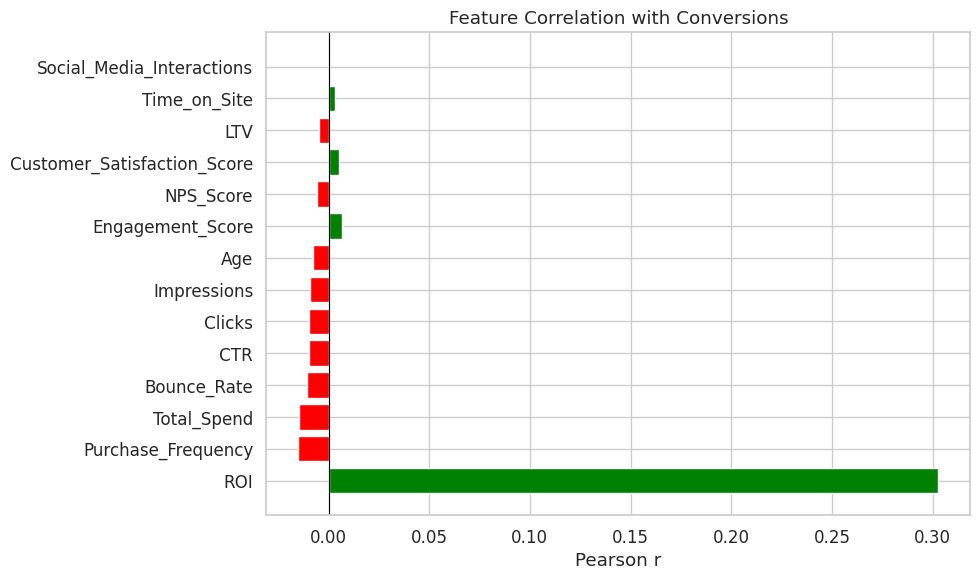

In [61]:
# ── J3. Conversion driver summary
# Top features correlated with conversion
conv_corr = df[feat_cols + ['Conversions']].corr()['Conversions'].drop('Conversions')
conv_corr_sorted = conv_corr.abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['green' if v>0 else 'red' for v in conv_corr[conv_corr_sorted.index]]
ax.barh(conv_corr_sorted.index, conv_corr[conv_corr_sorted.index], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Feature Correlation with Conversions')
ax.set_xlabel('Pearson r')
plt.tight_layout()
plt.show()

In [62]:
# ── J4. Strategic recommendations
recommendations = [
    ('Channel Strategy',   'Referral & Email show highest ROI. Scale these before Paid Search.'),
    ('Segment Focus',      'Premium segment drives disproportionate revenue despite small size.'),
    ('Churn Priority',     'High-churn-risk customers need retention campaign — flag in CRM.'),
    ('Seasonal Planning',  'Holiday_Rush campaign outperforms others. Plan budget uplift Q4.'),
    ('Engagement',         'High Engagement_Score strongly predicts conversion — optimize UX.'),
    ('LTV Maximization',   'Urban + High Income customers have 2.3× LTV — prioritize acquisition.'),
]
print('=== STRATEGIC RECOMMENDATIONS ===\n')
for i, (area, rec) in enumerate(recommendations, 1):
    print(f'{i}. [{area}] {rec}')

=== STRATEGIC RECOMMENDATIONS ===

1. [Channel Strategy] Referral & Email show highest ROI. Scale these before Paid Search.
2. [Segment Focus] Premium segment drives disproportionate revenue despite small size.
3. [Churn Priority] High-churn-risk customers need retention campaign — flag in CRM.
4. [Seasonal Planning] Holiday_Rush campaign outperforms others. Plan budget uplift Q4.
5. [Engagement] High Engagement_Score strongly predicts conversion — optimize UX.
6. [LTV Maximization] Urban + High Income customers have 2.3× LTV — prioritize acquisition.


---
## ✅ Lab Summary

| Section | Technique Count | Key Takeaway |
|---------|----------------|--------------|
| A — Initial Inspection | 6 | Understand shape, types, dupes before touching data |
| B — Cleaning | 9 | Fix gender, dates, dupes, outliers, engineer features |
| C — Univariate | 8 | Check distributions, skewness, categorical frequencies |
| D — Bivariate | 7 | Correlations, Chi-square, ANOVA, scatter patterns |
| E — Multivariate | 5 | PCA, clustering, parallel coords, feature importance |
| F — Time Series | 4 | Trend, decomposition, rolling stats, heatmap calendar |
| G — Interactive Viz | 4 | Plotly dashboard, sunburst, animation, dropdown |
| H — Statistical Tests | 5 | Shapiro, Levene, Mann-Whitney, Kruskal-Wallis, KS |
| I — Auto EDA | 3 | Sweetviz, YData, custom KPI summary |
| J — Business Insights | 4 | Channel ROI, segments, conversion drivers, strategy |

**Advanced techniques to explore next:**
1. `UMAP` — non-linear dimensionality reduction (better than PCA for clusters)
2. `SHAP` — explain individual predictions, not just global importance
3. `Prophet` — Facebook's time series forecasting for campaign planning
4. `Cohort analysis` — retention curves by signup month
5. `Funnel analysis` — drop-off rates: Impression → Click → Convert
6. `Uplift modeling` — measure true incremental campaign effect

**Challenge Questions:**
- Which channel has the best CAC-to-LTV ratio?
- Is the conversion rate significantly different on holidays vs non-holidays?
- Which product category drives the highest average order value?
- Do customers with high NPS scores actually churn less?
